##Emotion Classification using NLP (SDG 10)

**Dataset:** Emotions Dataset for NLP (Govi, 2020) — Kaggle  
**Model:** Support Vector Machine — LinearSVC  
**SDG Goal:** SDG 10 — Reduced Inequalities  

---

In [ ]:
# Step 1 - Install NLTK
import subprocess
subprocess.run(['pip', 'install', '-q', 'nltk'], check=True)

import nltk

# Download the language resources we need
nltk.download('stopwords', quiet=True)   # list of common words to remove
nltk.download('punkt',     quiet=True)   # needed for tokenization
nltk.download('punkt_tab', quiet=True)   # updated punkt tables
nltk.download('wordnet',   quiet=True)   # needed for lemmatization
nltk.download('omw-1.4',   quiet=True)   # wordnet multilingual support

print('NLTK downloads complete.')

NLTK downloads complete.


In [ ]:
# Step 2 - Import all the libraries we need

import os
import string
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

# NLTK tools for preprocessing text
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer

# Sklearn for feature extraction and splitting
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection         import train_test_split
from sklearn.preprocessing           import MaxAbsScaler, label_binarize

# The two models we will use
from sklearn.svm         import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

# Evaluation tools
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# For creating graphs and charts
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

# Set up the stopwords and lemmatizer so we can use them later
STOPWORDS  = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print('All libraries imported successfully!')
print(f'Number of stopwords loaded: {len(STOPWORDS)}')

All libraries imported successfully!
Number of stopwords loaded: 198


In [ ]:
# Step 3 - Upload the dataset files from Kaggle

# The dataset we are using is the Emotions Dataset for NLP by Govi (2020)
# Download it from: https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp

# When you download it, you get 3 separate text files:
#   train.txt  - contains most of the data (around 16,000 sentences)
#   val.txt    - validation data (around 2,000 sentences)
#   test.txt   - test data (around 2,000 sentences)


# NOTE: This step is for Google Colab only.
# If running locally, skip this cell and place train.txt, val.txt and test.txt
# manually inside a ./dataset/ folder before running Step 4.
from google.colab import files
import shutil

# Create a folder to store the uploaded files
os.makedirs('./dataset', exist_ok=True)

print('Please upload all 3 files: train.txt, val.txt, test.txt')
print()

uploaded = files.upload()

# Move each uploaded file into the dataset folder
for filename in uploaded:
    shutil.move(filename, f'./dataset/{filename}')
    print(f'Saved: {filename}')

print()
print('Files now in dataset folder:', os.listdir('./dataset'))

Please upload all 3 files: train.txt, val.txt, test.txt



Saving test.txt to test.txt
Saving train.txt to train.txt
Saving val.txt to val.txt
Saved: test.txt
Saved: train.txt
Saved: val.txt

Files now in dataset folder: ['val.txt', 'test.txt', 'train.txt']


In [ ]:
# Step 4 - Combine all 3 files into one single dataset

print('Reading and combining the 3 files...')
print()

# We will load each file and store them in this list
all_parts = []

# These are the 3 files we expect
filenames = ['train.txt', 'val.txt', 'test.txt']

for filename in filenames:
    filepath = f'./dataset/{filename}'

    # Check the file exists before trying to read it
    if not os.path.exists(filepath):
        print(f'Warning: {filename} not found, skipping this file')
        continue

    # Read the file into a dataframe
    # sep=';' means the columns are separated by semicolons
    # header=None means there is no header row in the file
    df_part = pd.read_csv(
        filepath,
        sep=';',
        header=None,
        names=['text', 'label'],
        encoding='utf-8'
    )

    # Add a column to show which file each row came from
    # This is useful for transparency and checking
    df_part['source'] = filename

    all_parts.append(df_part)
    print(f'  {filename} loaded — {len(df_part):,} rows')

# Combine all the individual dataframes into one big dataframe
# ignore_index=True resets the row numbers from 0
df = pd.concat(all_parts, ignore_index=True)

# Basic cleaning - remove rows with missing values
df = df.dropna(subset=['text', 'label'])

# Remove extra spaces from text and label columns
df['text']  = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip()

# Remove duplicate sentences to avoid data leakage
rows_before = len(df)
df = df.drop_duplicates(subset=['text'])
rows_after  = len(df)

print()
print('=' * 55)
print('  COMBINED DATASET SUMMARY')
print('=' * 55)
print(f'  Rows from train.txt  : {len(all_parts[0]):,}')
print(f'  Rows from val.txt    : {len(all_parts[1]):,}')
print(f'  Rows from test.txt   : {len(all_parts[2]):,}')
print(f'  Total rows combined  : {rows_before:,}')
print(f'  Duplicate rows removed: {rows_before - rows_after:,}')
print(f'  Final dataset size   : {rows_after:,} samples')
print()
print('  How many samples per emotion class:')
class_counts = df['label'].value_counts()
for emotion, count in class_counts.items():
    percentage = count / len(df) * 100
    print(f'    {emotion:<10} : {count:>5,} samples  ({percentage:.1f}%)')
print('=' * 55)
print()
print('First 5 rows of the combined dataset:')
print(df[['text', 'label', 'source']].head().to_string(index=False))

Reading and combining the 3 files...

  train.txt loaded — 16,000 rows
  val.txt loaded — 2,000 rows
  test.txt loaded — 2,000 rows

  COMBINED DATASET SUMMARY
  Rows from train.txt  : 16,000
  Rows from val.txt    : 2,000
  Rows from test.txt   : 2,000
  Total rows combined  : 20,000
  Duplicate rows removed: 52
  Final dataset size   : 19,948 samples

  How many samples per emotion class:
    joy        : 6,739 samples  (33.8%)
    sadness    : 5,793 samples  (29.0%)
    anger      : 2,703 samples  (13.6%)
    fear       : 2,369 samples  (11.9%)
    love       : 1,630 samples  (8.2%)
    surprise   :   714 samples  (3.6%)

First 5 rows of the combined dataset:
                                                                                                        text   label    source
                                                                                     i didnt feel humiliated sadness train.txt
i can go from feeling so hopeless to so damned hopeful just from being arou

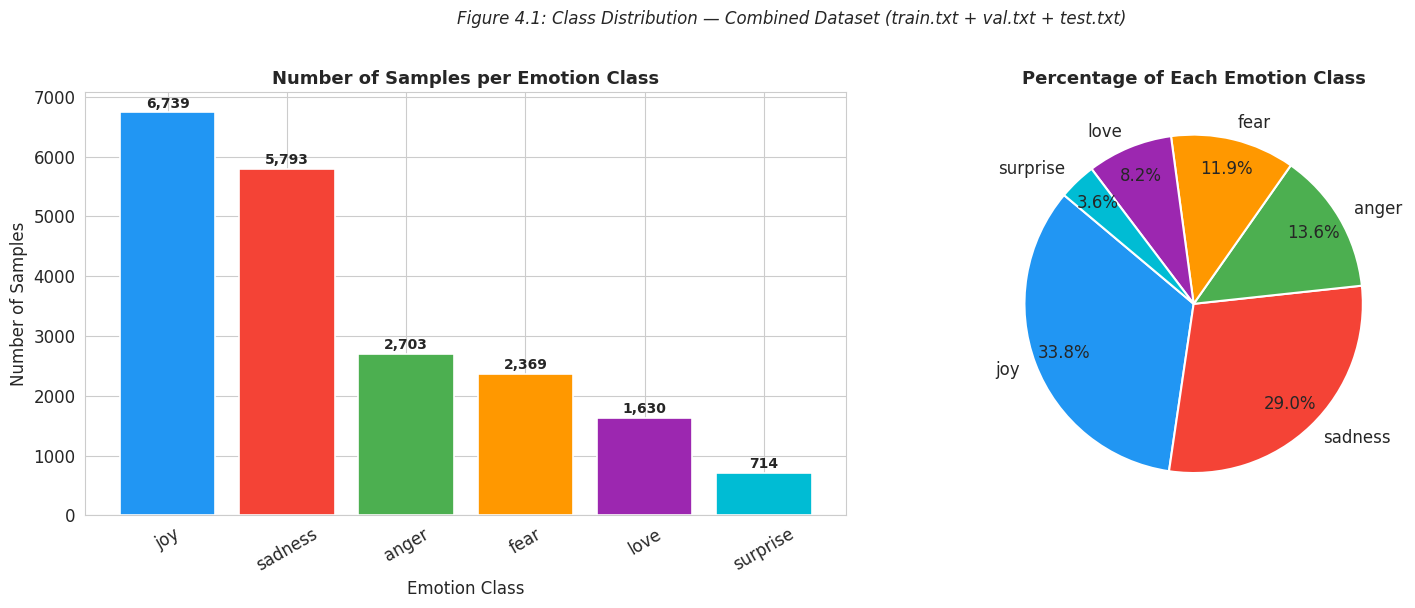

Chart saved as class_distribution.png

Observation: joy and sadness dominate the dataset.
Surprise only has around 2-3% of total samples.
We handle this imbalance using stratify=y in the split
and class_weight=balanced when training the SVM.


In [ ]:
# Step 5 - Show the class distribution in a chart

emotion_counts = df['label'].value_counts().sort_values(ascending=False)

# Choose one colour for each emotion class
colours = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left chart - bar chart showing count per class
bars = axes[0].bar(
    emotion_counts.index,
    emotion_counts.values,
    color=colours,
    edgecolor='white',
    linewidth=1.2
)
axes[0].set_title('Number of Samples per Emotion Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion Class')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=30)

# Add the count number on top of each bar
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Right chart - pie chart showing percentage per class
axes[1].pie(
    emotion_counts.values,
    labels=emotion_counts.index,
    autopct='%1.1f%%',
    colors=colours,
    startangle=140,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Percentage of Each Emotion Class', fontsize=13, fontweight='bold')

plt.suptitle(
    'Figure 4.1: Class Distribution — Combined Dataset (train.txt + val.txt + test.txt)',
    fontsize=12, y=1.01, style='italic'
)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Chart saved as class_distribution.png')
print()
print('Observation: joy and sadness dominate the dataset.')
print('Surprise only has around 2-3% of total samples.')
print('We handle this imbalance using stratify=y in the split')
print('and class_weight=balanced when training the SVM.')

In [ ]:
# Step 6 - Text Preprocessing
def preprocess_text(text):
    """
    Takes a raw sentence and cleans it through 5 steps.
    Returns a cleaned string ready for TF-IDF.

    Example:
        Input:  'I am Feeling SO Angry!'
        Output: 'feel angry'
    """

    # Handle cases where the input is not a string
    if not isinstance(text, str):
        return ''

    # Step 1 - Make everything lowercase
    text = text.lower()

    # Step 2 - Remove all punctuation marks
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 3 - Tokenize: split into a list of individual words
    tokens = word_tokenize(text)

    # Step 4 - Remove stopwords and keep only actual words (no numbers)
    tokens = [word for word in tokens if word not in STOPWORDS and word.isalpha()]

    # Step 5 - Lemmatize each word to its base form
    # pos='v' means we treat each word as a verb
    tokens = [lemmatizer.lemmatize(word, pos='v') for word in tokens]

    # Join the tokens back into a single string
    return ' '.join(tokens)


# Apply the preprocessing function to every row in the dataset
print(f'Preprocessing {len(df):,} sentences...')
df['cleaned_text'] = df['text'].apply(preprocess_text)
print('Preprocessing done!')
print()

# Show examples so we can see what each step does
print('PREPROCESSING EXAMPLES - showing each step:')
print('-' * 65)

example_sentences = [
    df['text'].iloc[0],
    df['text'].iloc[10],
    df['text'].iloc[50],
]

for sentence in example_sentences:
    # Apply each step one at a time to show what changes
    after_step1 = sentence.lower()
    after_step2 = after_step1.translate(str.maketrans('', '', string.punctuation))
    after_step3 = word_tokenize(after_step2)
    after_step4 = [w for w in after_step3 if w not in STOPWORDS and w.isalpha()]
    after_step5 = [lemmatizer.lemmatize(w, pos='v') for w in after_step4]

    print(f'  Original       : {sentence}')
    print(f'  After Step 1   : {after_step1[:60]}')
    print(f'  After Step 2   : {after_step2[:60]}')
    print(f'  After Step 3   : {after_step3[:7]}')
    print(f'  After Step 4   : {after_step4[:7]}')
    print(f'  After Step 5   : {after_step5[:7]}')
    print(f'  Final result   : {" ".join(after_step5)}')
    print('-' * 65)

# Prepare our features (X) and labels (y) for the model
X = df['cleaned_text'].values  # cleaned text sentences
y = df['label'].values         # emotion labels

print(f'Total samples ready for training: {len(X):,}')

Preprocessing 19,948 sentences...
Preprocessing done!

PREPROCESSING EXAMPLES - showing each step:
-----------------------------------------------------------------
  Original       : i didnt feel humiliated
  After Step 1   : i didnt feel humiliated
  After Step 2   : i didnt feel humiliated
  After Step 3   : ['i', 'didnt', 'feel', 'humiliated']
  After Step 4   : ['didnt', 'feel', 'humiliated']
  After Step 5   : ['didnt', 'feel', 'humiliate']
  Final result   : didnt feel humiliate
-----------------------------------------------------------------
  Original       : i feel like i have to make the suffering i m seeing mean something
  After Step 1   : i feel like i have to make the suffering i m seeing mean som
  After Step 2   : i feel like i have to make the suffering i m seeing mean som
  After Step 3   : ['i', 'feel', 'like', 'i', 'have', 'to', 'make']
  After Step 4   : ['feel', 'like', 'make', 'suffering', 'seeing', 'mean', 'something']
  After Step 5   : ['feel', 'like', 'make

In [ ]:
# Step 7 - Split the dataset into Training and Testing sets
print('Splitting dataset into training and test sets...')
print()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,               # our cleaned text
    y,               # our emotion labels
    test_size=0.20,  # 20% for testing
    random_state=42, # same split every time
    stratify=y       # keep class proportions balanced
)

print('Split complete!')
print()
print('=' * 55)
print('  SPLIT RESULTS')
print('=' * 55)
print(f'  Total samples   : {len(X):,}')
print(f'  Training set    : {len(X_train_raw):,} samples ({len(X_train_raw)/len(X)*100:.1f}%)')
print(f'  Test set        : {len(X_test_raw):,} samples  ({len(X_test_raw)/len(X)*100:.1f}%)')
print()
print('  Class counts in each split:')
print(f'  {"Emotion":<12} {"Train":>8} {"Test":>8} {"Train %":>9} {"Test %":>9}')
print('  ' + '-' * 52)

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

for emotion in sorted(set(y)):
    tr    = train_counts.get(emotion, 0)
    te    = test_counts.get(emotion, 0)
    tr_pc = tr / len(y_train) * 100
    te_pc = te / len(y_test)  * 100
    print(f'  {emotion:<12} {tr:>8,} {te:>8,} {tr_pc:>8.1f}% {te_pc:>8.1f}%')

print('=' * 55)
print()
print('Notice: the percentage for each class is almost identical')
print('in both train and test. This is what stratify=y does.')
print('It ensures each emotion is fairly represented in both sets.')

Splitting dataset into training and test sets...

Split complete!

  SPLIT RESULTS
  Total samples   : 19,948
  Training set    : 15,958 samples (80.0%)
  Test set        : 3,990 samples  (20.0%)

  Class counts in each split:
  Emotion         Train     Test   Train %    Test %
  ----------------------------------------------------
  anger           2,163      540     13.6%     13.5%
  fear            1,895      474     11.9%     11.9%
  joy             5,391    1,348     33.8%     33.8%
  love            1,304      326      8.2%      8.2%
  sadness         4,634    1,159     29.0%     29.0%
  surprise          571      143      3.6%      3.6%

Notice: the percentage for each class is almost identical
in both train and test. This is what stratify=y does.
It ensures each emotion is fairly represented in both sets.


In [ ]:
# Step 8 - TF-IDF Feature Extraction
print('Converting text to TF-IDF numbers...')

vectorizer = TfidfVectorizer(
    max_features = 30000,  # use top 30,000 words
    ngram_range  = (1, 2), # single words and word pairs
    min_df       = 2,      # ignore words in only 1 document
    max_df       = 0.95,   # ignore words in 95%+ of documents
    sublinear_tf = True    # use log scaling for word counts
)

# Learn the vocabulary from training data and convert to numbers
X_train = vectorizer.fit_transform(X_train_raw)

# Apply the SAME vocabulary to test data (no re-learning)
X_test = vectorizer.transform(X_test_raw)

# Work out how sparse the matrix is
total_values   = X_train.shape[0] * X_train.shape[1]
nonzero_values = X_train.nnz
sparsity       = (1 - nonzero_values / total_values) * 100

print('TF-IDF complete!')
print()
print('=' * 55)
print('  TF-IDF RESULTS')
print('=' * 55)
print(f'  Vocabulary size  : {len(vectorizer.vocabulary_):,} unique words/phrases')
print(f'  Training matrix  : {X_train.shape[0]:,} rows x {X_train.shape[1]:,} columns')
print(f'  Test matrix      : {X_test.shape[0]:,} rows  x {X_test.shape[1]:,} columns')
print(f'  Matrix sparsity  : {sparsity:.1f}% of values are zero')
print('=' * 55)
print()
print('The vocabulary was learned from training data only.')
print('The test data was transformed using the same vocabulary.')
print('This prevents data leakage.')

Converting text to TF-IDF numbers...
TF-IDF complete!

  TF-IDF RESULTS
  Vocabulary size  : 16,356 unique words/phrases
  Training matrix  : 15,958 rows x 16,356 columns
  Test matrix      : 3,990 rows  x 16,356 columns
  Matrix sparsity  : 99.9% of values are zero

The vocabulary was learned from training data only.
The test data was transformed using the same vocabulary.
This prevents data leakage.


Testing C = 0.1, 1.0, and 10.0 to find the best value...

  C = 0.1     Accuracy = 89.00%   F1 = 89.19%
  C = 1.0     Accuracy = 89.97%   F1 = 90.01% <-- we will use this one
  C = 10.0    Accuracy = 88.35%   F1 = 88.31%

Full results table:
 C Value  Accuracy  Precision  Recall  F1 Score
     0.1     89.00      89.76   89.00     89.19
     1.0     89.97      90.07   89.97     90.01
    10.0     88.35      88.30   88.35     88.31

C = 1.0 gives the best F1 score so we will use it for our final model.


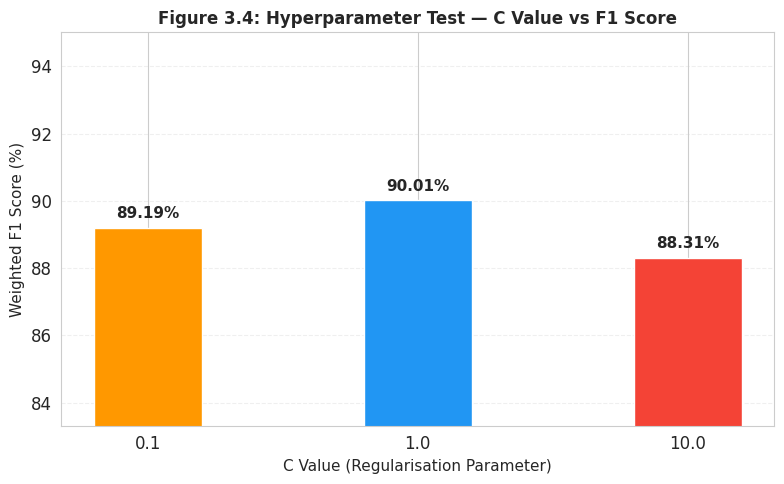

Chart saved as hyperparameter_sensitivity.png


In [ ]:
# Step 9 - Try different values of C to find the best one
print('Testing C = 0.1, 1.0, and 10.0 to find the best value...')
print()

c_values_to_try = [0.1, 1.0, 10.0]
sensitivity_results = []

for c in c_values_to_try:

    # Train a temporary model with this value of C
    temp_model = LinearSVC(
        C            = c,
        max_iter     = 2000,
        class_weight = 'balanced',
        dual         = True,
        random_state = 42
    )
    temp_model.fit(X_train, y_train)

    # Test it on the test set
    temp_predictions = temp_model.predict(X_test)

    # Calculate all four metrics
    acc = accuracy_score(y_test, temp_predictions)
    pre = precision_score(y_test, temp_predictions, average='weighted', zero_division=0)
    rec = recall_score(y_test, temp_predictions, average='weighted', zero_division=0)
    f1  = f1_score(y_test, temp_predictions, average='weighted', zero_division=0)

    sensitivity_results.append({
        'C Value':   c,
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(pre * 100, 2),
        'Recall':    round(rec * 100, 2),
        'F1 Score':  round(f1  * 100, 2)
    })

    # Mark the best one
    note = ' <-- we will use this one' if c == 1.0 else ''
    print(f'  C = {c:<5}   Accuracy = {acc*100:.2f}%   F1 = {f1*100:.2f}%{note}')

print()
print('Full results table:')
results_df = pd.DataFrame(sensitivity_results)
print(results_df.to_string(index=False))
print()
print('C = 1.0 gives the best F1 score so we will use it for our final model.')

# Save the chart showing F1 vs C value
fig, ax = plt.subplots(figsize=(8, 5))
c_labels   = [str(c) for c in c_values_to_try]
f1_per_c   = [r['F1 Score'] for r in sensitivity_results]
bar_colors = ['#FF9800', '#2196F3', '#F44336']

bars = ax.bar(c_labels, f1_per_c, color=bar_colors, edgecolor='white', width=0.4)

# Add the F1 value on top of each bar
for bar, val in zip(bars, f1_per_c):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.set_title('Figure 3.4: Hyperparameter Test — C Value vs F1 Score', fontsize=12, fontweight='bold')
ax.set_xlabel('C Value (Regularisation Parameter)', fontsize=11)
ax.set_ylabel('Weighted F1 Score (%)', fontsize=11)
ax.set_ylim(min(f1_per_c) - 5, max(f1_per_c) + 5)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('hyperparameter_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved as hyperparameter_sensitivity.png')

In [ ]:
# Step 10 - Train the main model: LinearSVC (Support Vector Machine)
print('Training the SVM model (LinearSVC) with C = 1.0...')
print()

svm_model = LinearSVC(
    C            = 1.0,        # best value from our test above
    max_iter     = 2000,       # maximum training iterations
    class_weight = 'balanced', # handles imbalanced classes fairly
    dual         = True,       # more efficient when features > samples
    random_state = 42          # makes results reproducible
)

svm_model.fit(X_train, y_train)

print('SVM training complete!')
print()
print('Model settings:')
print(f'  Algorithm        : LinearSVC (Support Vector Machine)')
print(f'  C value          : {svm_model.C}')
print(f'  class_weight     : {svm_model.class_weight}')
print(f'  max_iter         : {svm_model.max_iter}')
print(f'  Multi-class      : One-vs-Rest (trains 6 binary classifiers)')
print(f'  Emotion classes  : {list(svm_model.classes_)}')

Training the SVM model (LinearSVC) with C = 1.0...

SVM training complete!

Model settings:
  Algorithm        : LinearSVC (Support Vector Machine)
  C value          : 1.0
  class_weight     : balanced
  max_iter         : 2000
  Multi-class      : One-vs-Rest (trains 6 binary classifiers)
  Emotion classes  : ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


Generating learning curve (this may take 30–60 seconds)...
Using 5-fold cross-validation at each training size.



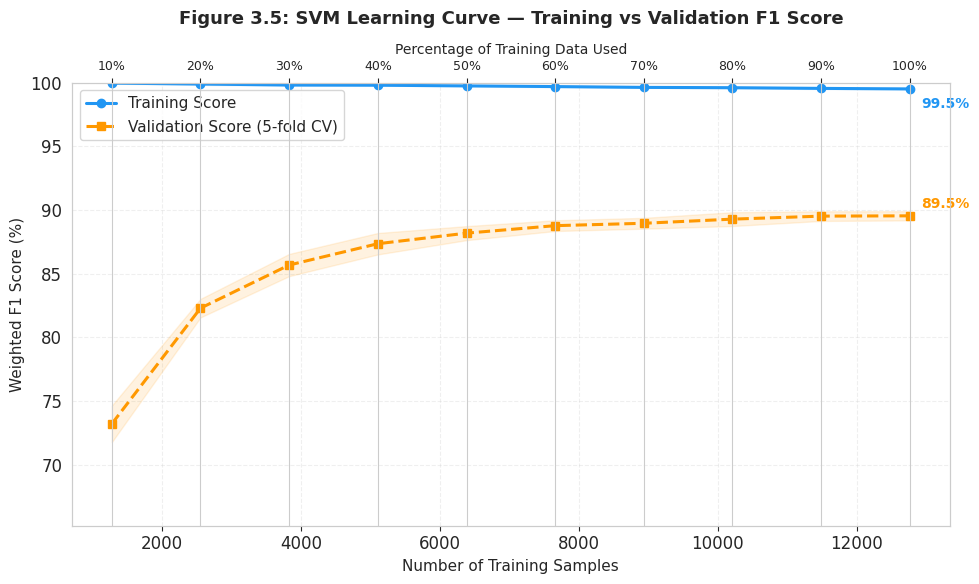

Chart saved as learning_curve.png

Summary of training and validation scores:
   Samples    Train F1      Val F1       Gap
  --------------------------------------------
     1,276      99.97%      73.21%    26.76%
     2,553      99.90%      82.29%    17.60%
     3,829      99.82%      85.68%    14.14%
     5,106      99.80%      87.35%    12.45%
     6,383      99.75%      88.19%    11.57%
     7,659      99.70%      88.77%    10.92%
     8,936      99.63%      88.96%    10.67%
    10,212      99.61%      89.29%    10.32%
    11,489      99.56%      89.52%    10.03%
    12,766      99.51%      89.54%     9.97%

Interpretation:
  A small gap between Training and Validation scores means
  the model generalises well and is not overfitting.


In [ ]:
# Step 10b - Training and Validation Learning Curve
from sklearn.model_selection import learning_curve
import numpy as np

print('Generating learning curve (this may take 30–60 seconds)...')
print('Using 5-fold cross-validation at each training size.')
print()

# Define the fractions of training data to evaluate
train_sizes_frac = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]

# learning_curve returns:
#   train_sizes_abs  - actual number of training samples used
#   train_scores     - F1 on the training fold (shape: sizes x folds)
#   val_scores       - F1 on the validation fold (shape: sizes x folds)
train_sizes_abs, train_scores, val_scores = learning_curve(
    LinearSVC(C=1.0, max_iter=2000, class_weight='balanced',
              dual=True, random_state=42),
    X_train,          # full training matrix
    y_train,          # training labels
    train_sizes  = train_sizes_frac,
    cv           = 5,                   # 5-fold cross-validation
    scoring      = 'f1_weighted',       # same metric as our evaluation
    n_jobs       = -1,                  # use all CPU cores
    shuffle      = True,
    random_state = 42
)

# Compute mean and standard deviation across the 5 folds
train_mean = train_scores.mean(axis=1) * 100
train_std  = train_scores.std(axis=1)  * 100
val_mean   = val_scores.mean(axis=1)   * 100
val_std    = val_scores.std(axis=1)    * 100

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Training score line + shaded std band
ax.plot(train_sizes_abs, train_mean,
        color='#2196F3', marker='o', linewidth=2.2,
        markersize=6, label='Training Score')
ax.fill_between(train_sizes_abs,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.12, color='#2196F3')

# Validation score line + shaded std band
ax.plot(train_sizes_abs, val_mean,
        color='#FF9800', marker='s', linewidth=2.2,
        markersize=6, linestyle='--', label='Validation Score (5-fold CV)')
ax.fill_between(train_sizes_abs,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.12, color='#FF9800')

# Annotate final values
ax.annotate(f"{train_mean[-1]:.1f}%",
            xy=(train_sizes_abs[-1], train_mean[-1]),
            xytext=(8, -14), textcoords='offset points',
            color='#2196F3', fontsize=10, fontweight='bold')

ax.annotate(f"{val_mean[-1]:.1f}%",
            xy=(train_sizes_abs[-1], val_mean[-1]),
            xytext=(8, 6), textcoords='offset points',
            color='#FF9800', fontsize=10, fontweight='bold')

ax.set_title('Figure 3.5: SVM Learning Curve — Training vs Validation F1 Score',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Number of Training Samples', fontsize=11)
ax.set_ylabel('Weighted F1 Score (%)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_ylim(max(0, min(val_mean) - 8), min(100, max(train_mean) + 6))

# Secondary x-axis showing percentage of training data
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(train_sizes_abs)
ax2.set_xticklabels([f'{int(p*100)}%' for p in train_sizes_frac], fontsize=9)
ax2.set_xlabel('Percentage of Training Data Used', fontsize=10)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved as learning_curve.png')
print()

# Print a concise summary table
print('Summary of training and validation scores:')
print(f'  {"Samples":>8}  {"Train F1":>10}  {"Val F1":>10}  {"Gap":>8}')
print('  ' + '-' * 44)
for n, tr, va in zip(train_sizes_abs, train_mean, val_mean):
    gap = tr - va
    print(f'  {n:>8,}  {tr:>9.2f}%  {va:>9.2f}%  {gap:>7.2f}%')
print()
print('Interpretation:')
print('  A small gap between Training and Validation scores means')
print('  the model generalises well and is not overfitting.')


In [ ]:
# Step 11 - Train the Naive Bayes baseline model
print('Training the Naive Bayes baseline model...')

# Scale TF-IDF values to [0,1] range for Naive Bayes
scaler     = MaxAbsScaler()
X_train_nb = scaler.fit_transform(X_train)  # learn scaling from train
X_test_nb  = scaler.transform(X_test)       # apply same scaling to test

# Train Naive Bayes with Laplace smoothing
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_nb, y_train)

print('Naive Bayes training complete!')
print(f'  Laplace smoothing (alpha): {nb_model.alpha}')
print(f'  Classes: {list(nb_model.classes_)}')

Training the Naive Bayes baseline model...
Naive Bayes training complete!
  Laplace smoothing (alpha): 1.0
  Classes: [np.str_('anger'), np.str_('fear'), np.str_('joy'), np.str_('love'), np.str_('sadness'), np.str_('surprise')]


In [ ]:
# Step 12 - Generate predictions on the test set

# Get predictions from both models
y_pred_svm = svm_model.predict(X_test)
y_pred_nb  = nb_model.predict(X_test_nb)

print(f'Predictions generated for {len(y_pred_svm):,} test samples.')
print()

# Show the first 10 predictions from the SVM
print('First 10 predictions from SVM:')
print(f'  {"Sentence":<48} {"Real Label":>12} {"Predicted":>10} {"":>7}')
print('  ' + '-' * 82)

for i in range(min(10, len(y_test))):
    sentence = X_test_raw[i]
    display  = (sentence[:45] + '...') if len(sentence) > 48 else sentence
    correct  = 'CORRECT' if y_test[i] == y_pred_svm[i] else 'WRONG'
    print(f'  {display:<48} {y_test[i]:>12} {y_pred_svm[i]:>10}  {correct}')

Predictions generated for 3,990 test samples.

First 10 predictions from SVM:
  Sentence                                           Real Label  Predicted        
  ----------------------------------------------------------------------------------
  still feel devastate                                  sadness    sadness  CORRECT
  say feel guilty begin give reason benefit ass...      sadness    sadness  CORRECT
  hi tech color club holiday splendor sally han...          joy        joy  CORRECT
  feel pretty spot son                                      joy        joy  CORRECT
  feel like amaze series epic movie theater                 joy   surprise  WRONG
  see shallow many live try give love atention ...        anger      anger  CORRECT
  feel bitter cancer relegate unnecessary meet ...        anger      anger  CORRECT
  read novels make feel relax                               joy        joy  CORRECT
  sure im alone say feel drain events past week         sadness    sadness  CORRECT


In [ ]:
# Step 13 - Evaluate both models using 4 metrics
def evaluate_model(y_true, y_pred, model_name):
    """Calculate and print all 4 evaluation metrics."""

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('=' * 55)
    print(f'  Results for: {model_name}')
    print('=' * 55)
    print(f'  Accuracy  : {acc * 100:.2f}%')
    print(f'  Precision : {pre * 100:.2f}%')
    print(f'  Recall    : {rec * 100:.2f}%')
    print(f'  F1 Score  : {f1  * 100:.2f}%  (main metric)')
    print('=' * 55)
    print()
    print('  Per-class breakdown (one row per emotion):')
    print(classification_report(y_true, y_pred, zero_division=0))

    return acc, pre, rec, f1


# Evaluate both models
svm_acc, svm_pre, svm_rec, svm_f1 = evaluate_model(
    y_test, y_pred_svm, 'LinearSVC - SVM (Primary Model)'
)
nb_acc, nb_pre, nb_rec, nb_f1 = evaluate_model(
    y_test, y_pred_nb, 'Naive Bayes (Baseline)'
)

  Results for: LinearSVC - SVM (Primary Model)
  Accuracy  : 89.97%
  Precision : 90.07%
  Recall    : 89.97%
  F1 Score  : 90.01%  (main metric)

  Per-class breakdown (one row per emotion):
              precision    recall  f1-score   support

       anger       0.90      0.91      0.91       540
        fear       0.88      0.85      0.87       474
         joy       0.93      0.91      0.92      1348
        love       0.76      0.81      0.79       326
     sadness       0.94      0.94      0.94      1159
    surprise       0.75      0.76      0.75       143

    accuracy                           0.90      3990
   macro avg       0.86      0.87      0.86      3990
weighted avg       0.90      0.90      0.90      3990

  Results for: Naive Bayes (Baseline)
  Accuracy  : 75.39%
  Precision : 78.00%
  Recall    : 75.39%
  F1 Score  : 73.19%  (main metric)

  Per-class breakdown (one row per emotion):
              precision    recall  f1-score   support

       anger       0.89    

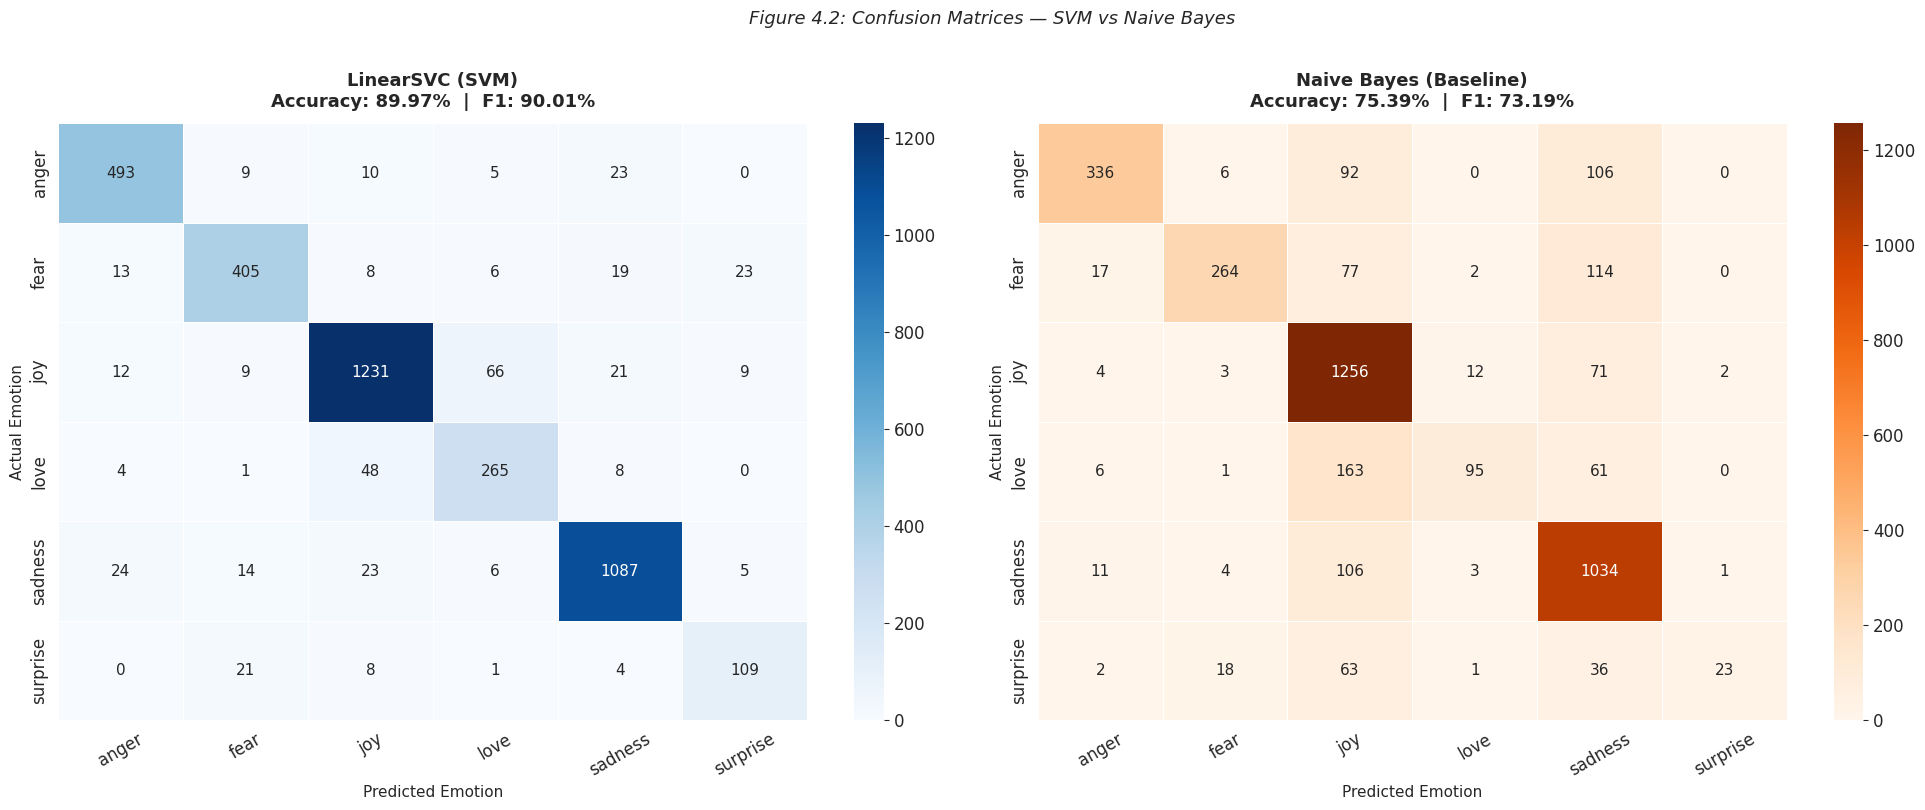

Saved: confusion_matrix.png


In [ ]:
# Step 14 - Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

emotion_labels = sorted(set(y_test))

for ax, predictions, title, colour_map in [
    (axes[0], y_pred_svm,
     f'LinearSVC (SVM)\nAccuracy: {svm_acc*100:.2f}%  |  F1: {svm_f1*100:.2f}%',
     'Blues'),
    (axes[1], y_pred_nb,
     f'Naive Bayes (Baseline)\nAccuracy: {nb_acc*100:.2f}%  |  F1: {nb_f1*100:.2f}%',
     'Oranges')
]:
    cm = confusion_matrix(y_test, predictions, labels=emotion_labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=colour_map,
        xticklabels=emotion_labels,
        yticklabels=emotion_labels,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        annot_kws={'size': 11}
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Emotion', fontsize=11)
    ax.set_ylabel('Actual Emotion', fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    'Figure 4.2: Confusion Matrices — SVM vs Naive Bayes',
    fontsize=13, y=1.01, style='italic'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

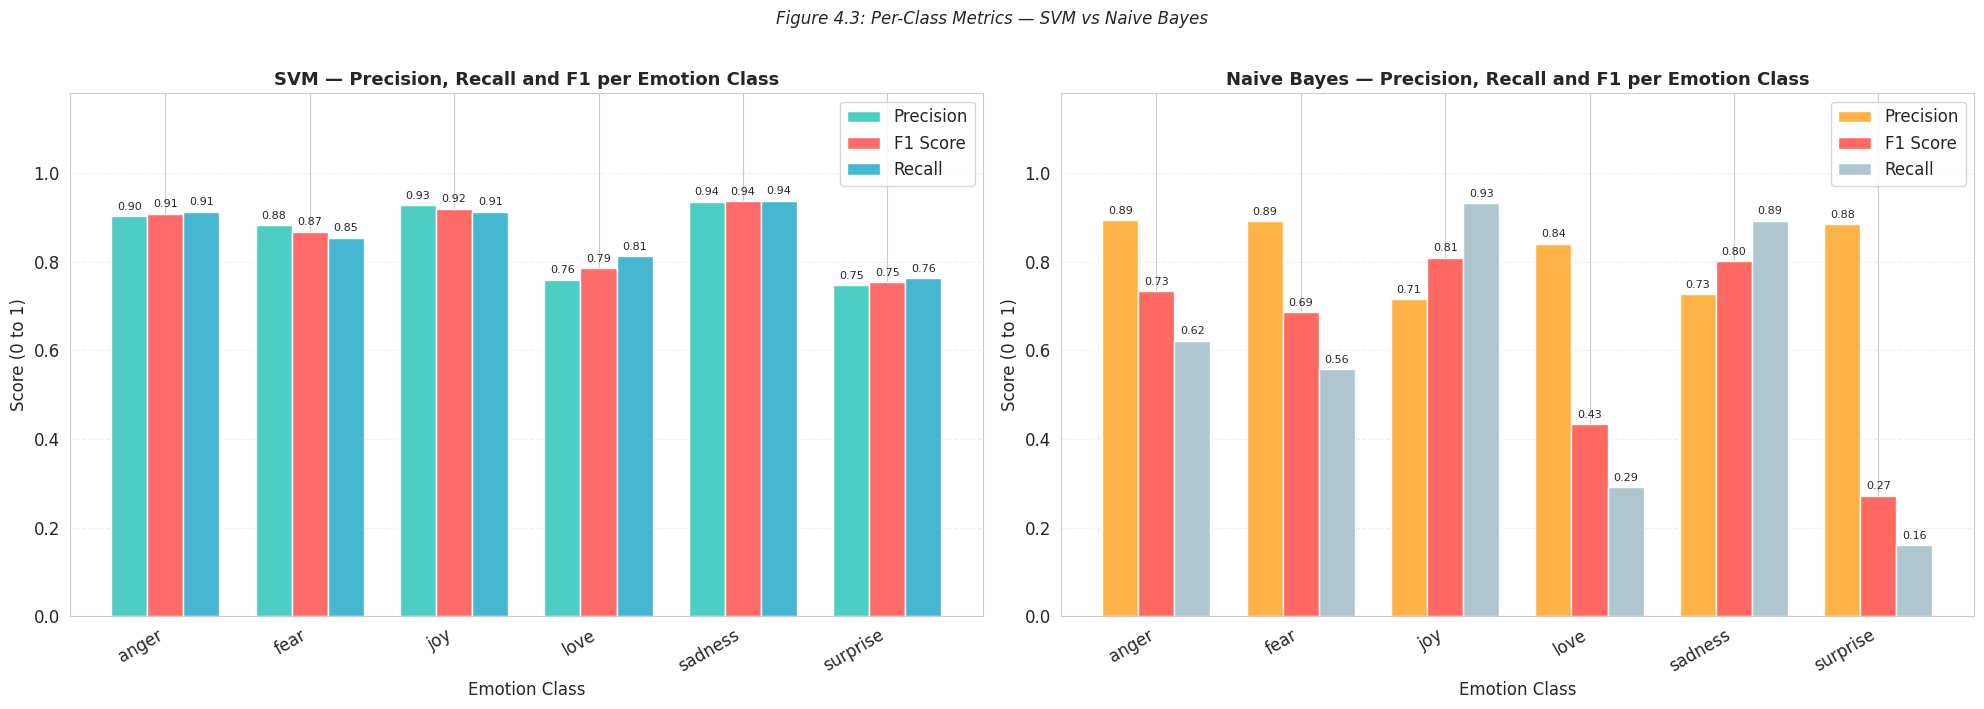

Saved: per_class_metrics.png


In [ ]:
# Step 15 - Bar chart showing precision, recall, F1 per emotion class

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, predictions, title, bar_colours in [
    (axes[0], y_pred_svm, 'SVM — Precision, Recall and F1 per Emotion Class',
     ['#4ECDC4', '#FF6B6B', '#45B7D1']),
    (axes[1], y_pred_nb,  'Naive Bayes — Precision, Recall and F1 per Emotion Class',
     ['#FFB347', '#FF6961', '#AEC6CF'])
]:
    report = classification_report(y_test, predictions, output_dict=True, zero_division=0)

    # Get the emotion class names (not the average rows)
    classes = [c for c in report if c not in ('accuracy', 'macro avg', 'weighted avg')]

    precisions = [report[c]['precision'] for c in classes]
    recalls    = [report[c]['recall']    for c in classes]
    f1_scores  = [report[c]['f1-score']  for c in classes]

    x = np.arange(len(classes))
    bar_width = 0.25

    # Draw three groups of bars
    b1 = ax.bar(x - bar_width, precisions, bar_width, label='Precision', color=bar_colours[0], edgecolor='white')
    b2 = ax.bar(x,             f1_scores,  bar_width, label='F1 Score',  color=bar_colours[1], edgecolor='white')
    b3 = ax.bar(x + bar_width, recalls,    bar_width, label='Recall',    color=bar_colours[2], edgecolor='white')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Emotion Class')
    ax.set_ylabel('Score (0 to 1)')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=30, ha='right')
    ax.set_ylim(0, 1.18)
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add score labels on top of each bar
    for bar_group in [b1, b2, b3]:
        for bar in bar_group:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8
            )

plt.suptitle(
    'Figure 4.3: Per-Class Metrics — SVM vs Naive Bayes',
    fontsize=12, y=1.01, style='italic'
)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: per_class_metrics.png')

Calibrating SVM to produce probability scores...

AUC score for each emotion class:
  anger       : AUC = 0.9898
  fear        : AUC = 0.9915
  joy         : AUC = 0.9846
  love        : AUC = 0.9801
  sadness     : AUC = 0.9917
  surprise    : AUC = 0.9919


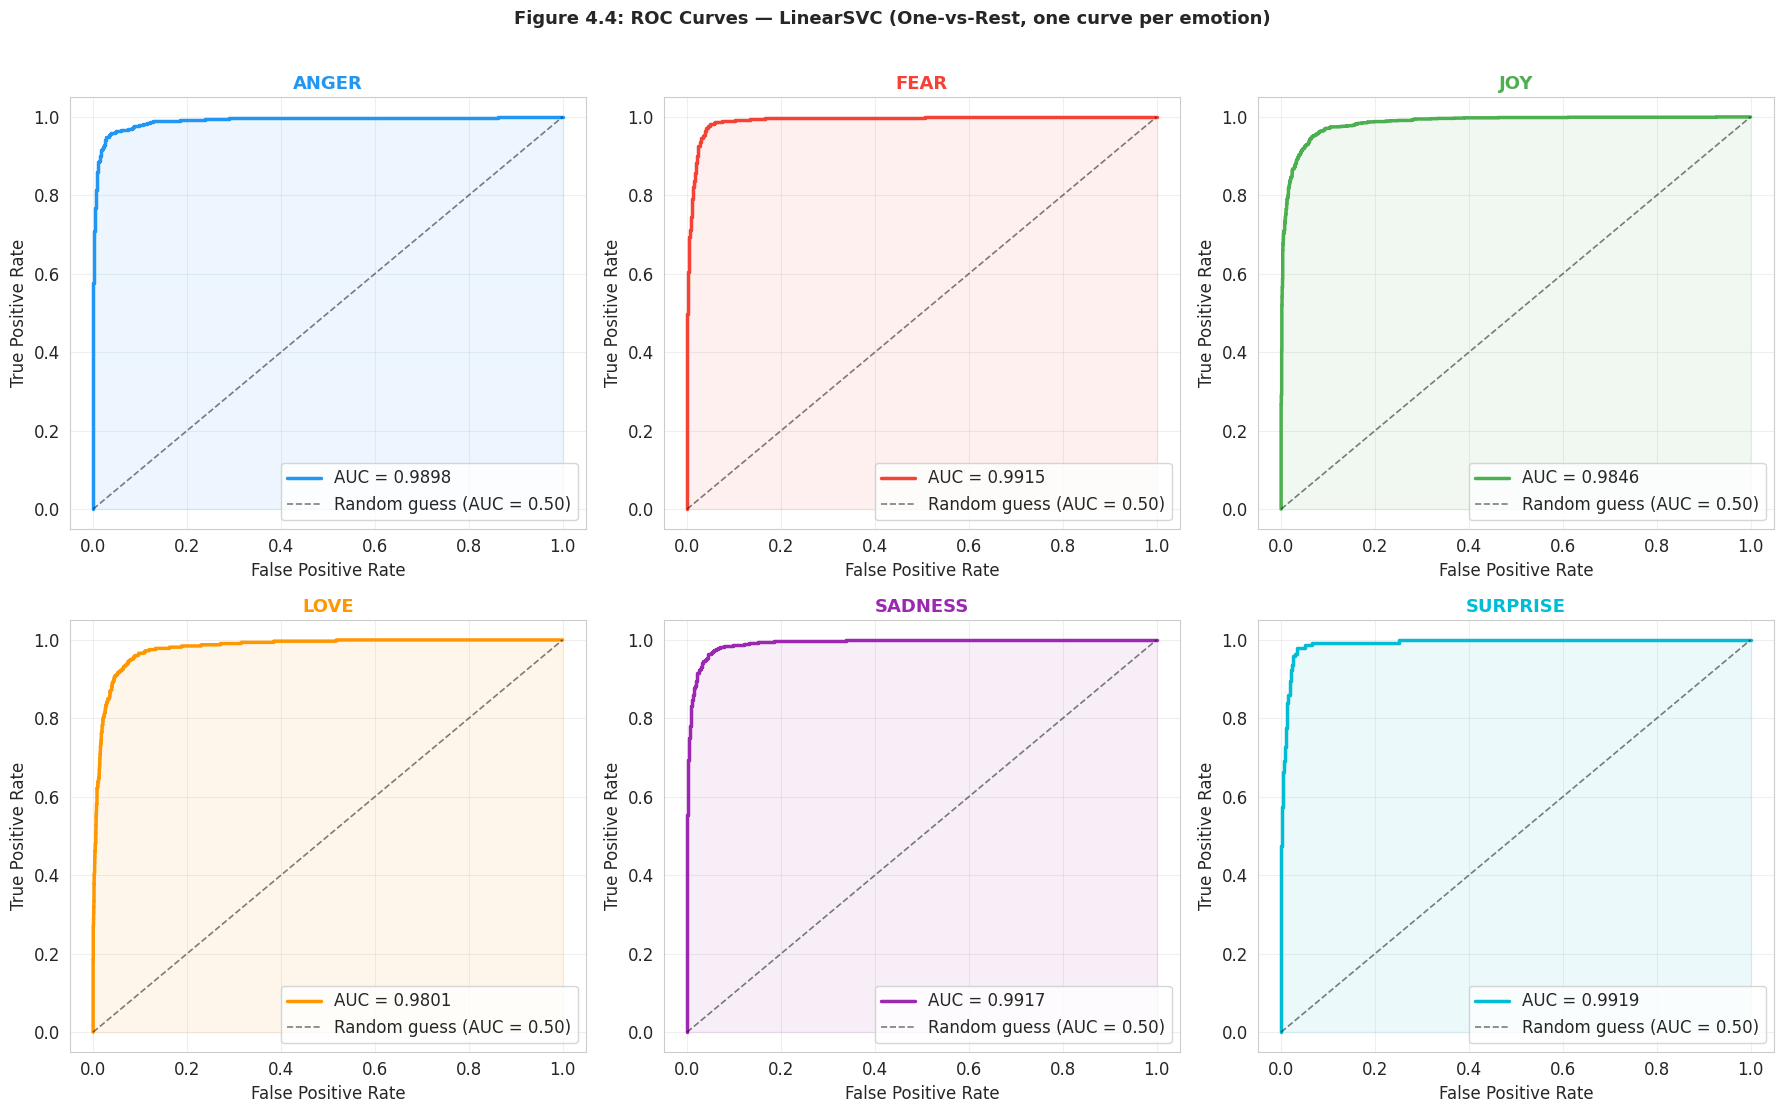

Saved: roc_curves.png


In [ ]:
# Step 16 - ROC Curves

print('Calibrating SVM to produce probability scores...')

calibrated_svm = CalibratedClassifierCV(svm_model, cv='prefit')
calibrated_svm.fit(X_train, y_train)

# Get probability scores for each emotion class
y_probabilities = calibrated_svm.predict_proba(X_test)

# Convert labels to binary format (one column per class)
class_names = list(svm_model.classes_)
y_binary    = label_binarize(y_test, classes=class_names)

# One colour for each emotion class
roc_colours = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

print()
print('AUC score for each emotion class:')

for i, (emotion, colour) in enumerate(zip(class_names, roc_colours)):

    # Calculate the ROC curve for this emotion
    false_pos_rate, true_pos_rate, _ = roc_curve(y_binary[:, i], y_probabilities[:, i])
    auc_score = auc(false_pos_rate, true_pos_rate)

    print(f'  {emotion:<12}: AUC = {auc_score:.4f}')

    # Plot the ROC curve
    axes[i].plot(false_pos_rate, true_pos_rate, color=colour, lw=2.5,
                 label=f'AUC = {auc_score:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5,
                 label='Random guess (AUC = 0.50)')
    axes[i].fill_between(false_pos_rate, true_pos_rate, alpha=0.08, color=colour)
    axes[i].set_title(emotion.upper(), fontsize=13, fontweight='bold', color=colour)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')
    axes[i].grid(alpha=0.3)

plt.suptitle(
    'Figure 4.4: ROC Curves — LinearSVC (One-vs-Rest, one curve per emotion)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

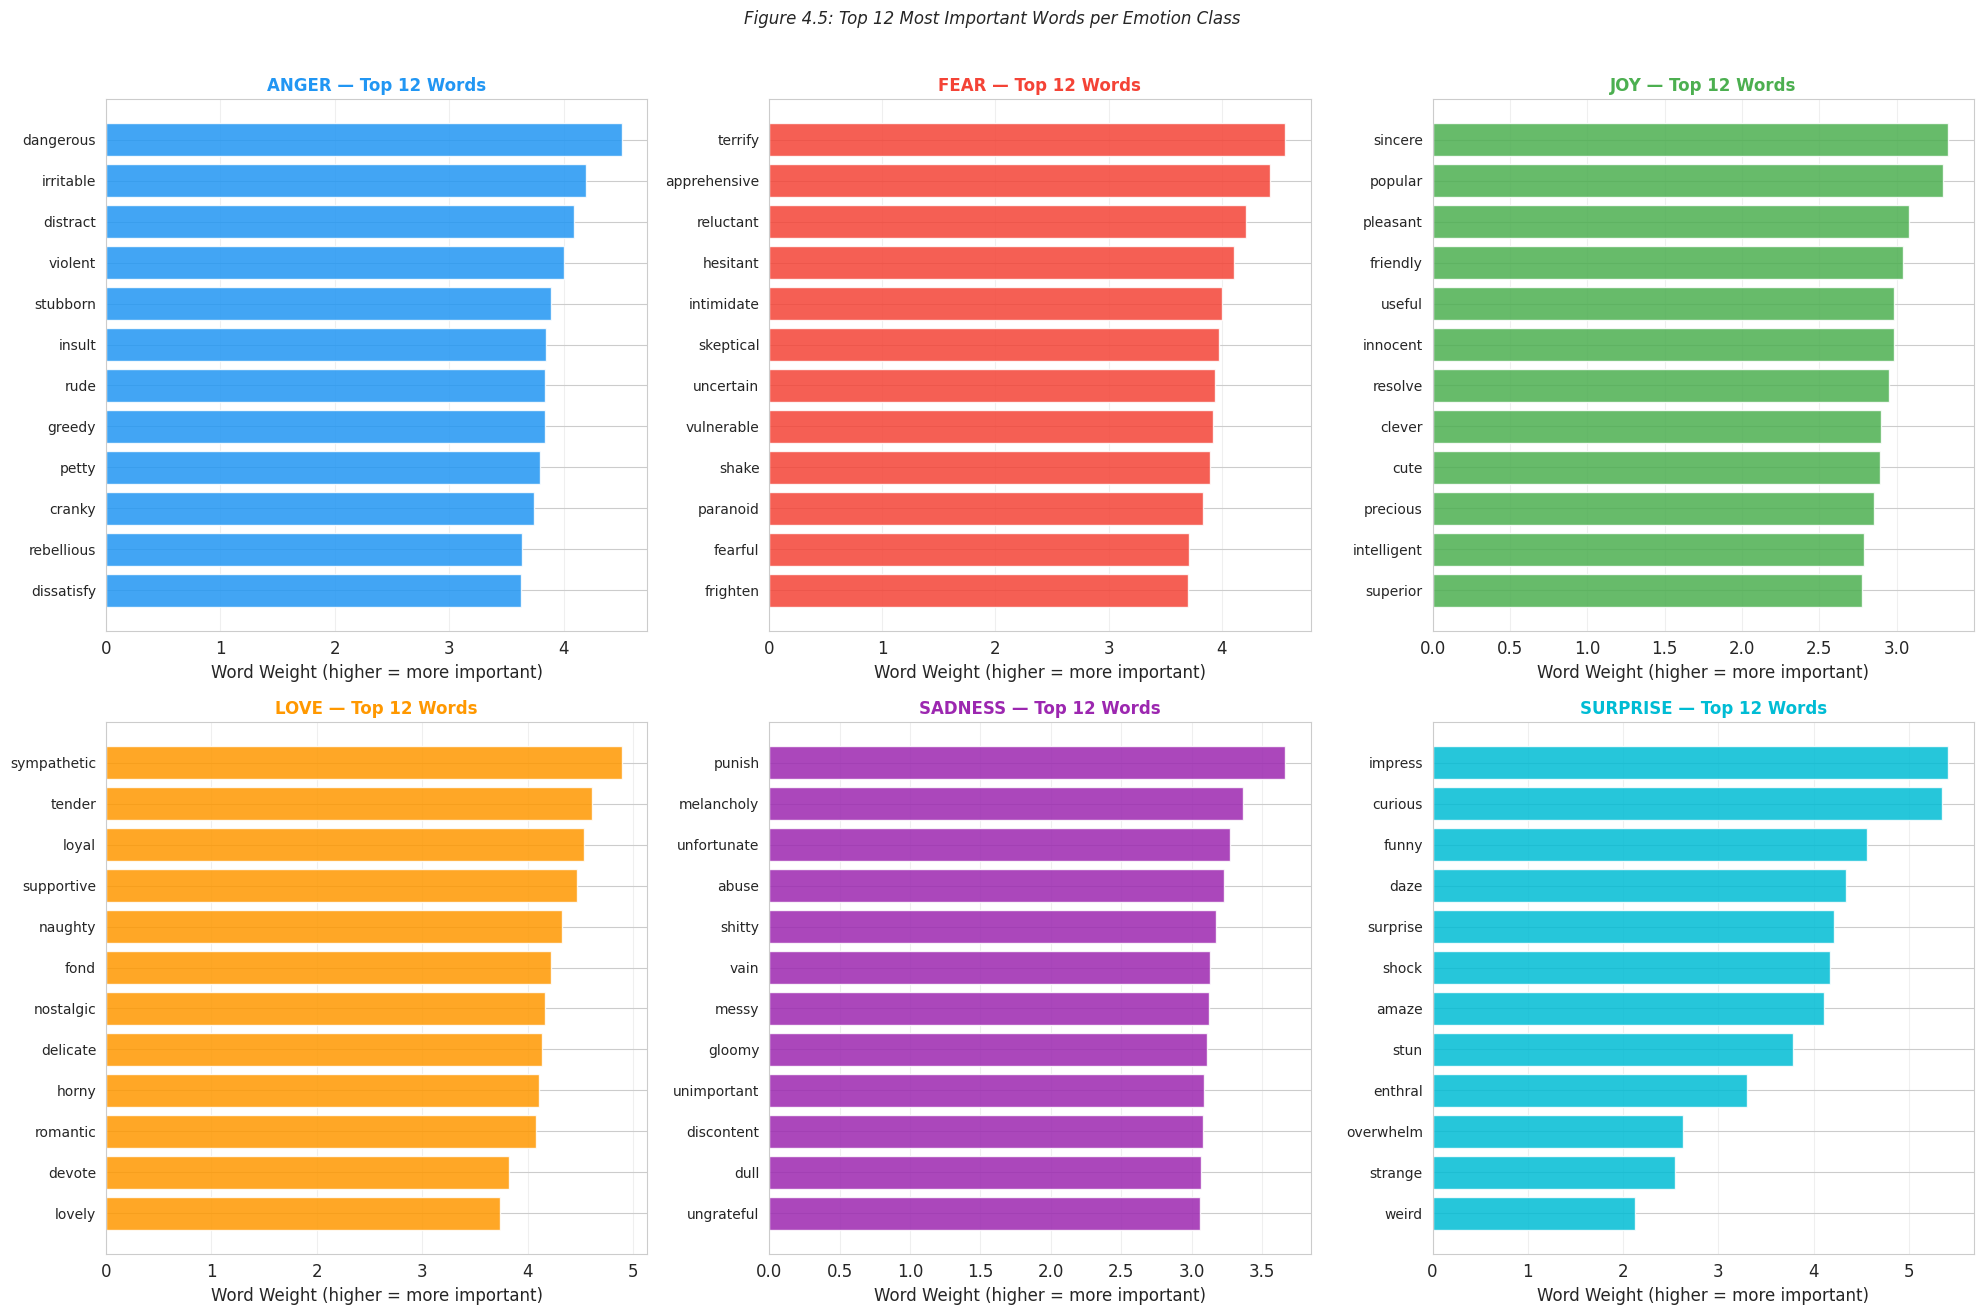

Saved: top_features.png


In [ ]:
# Step 17 - Top 12 most important words per emotion class

# Get all the vocabulary words in order
all_feature_names = np.array(vectorizer.get_feature_names_out())
top_n = 12

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for i, (emotion, colour) in enumerate(zip(svm_model.classes_, roc_colours)):

    # Get the weight of every word for this emotion class
    weights = svm_model.coef_[i]

    # Find the top 12 words with the highest weights
    top_indices = np.argsort(weights)[-top_n:][::-1]
    top_words   = all_feature_names[top_indices]
    top_weights = weights[top_indices]

    # Draw a horizontal bar chart
    axes[i].barh(
        range(top_n),
        top_weights[::-1],
        color=colour,
        alpha=0.85,
        edgecolor='white'
    )
    axes[i].set_yticks(range(top_n))
    axes[i].set_yticklabels(top_words[::-1], fontsize=10)
    axes[i].set_title(
        f'{emotion.upper()} — Top {top_n} Words',
        fontsize=12, fontweight='bold', color=colour
    )
    axes[i].set_xlabel('Word Weight (higher = more important)')
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle(
    'Figure 4.5: Top 12 Most Important Words per Emotion Class',
    fontsize=12, y=1.01, style='italic'
)
plt.tight_layout()
plt.savefig('top_features.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: top_features.png')

Generating word clouds for each emotion class...



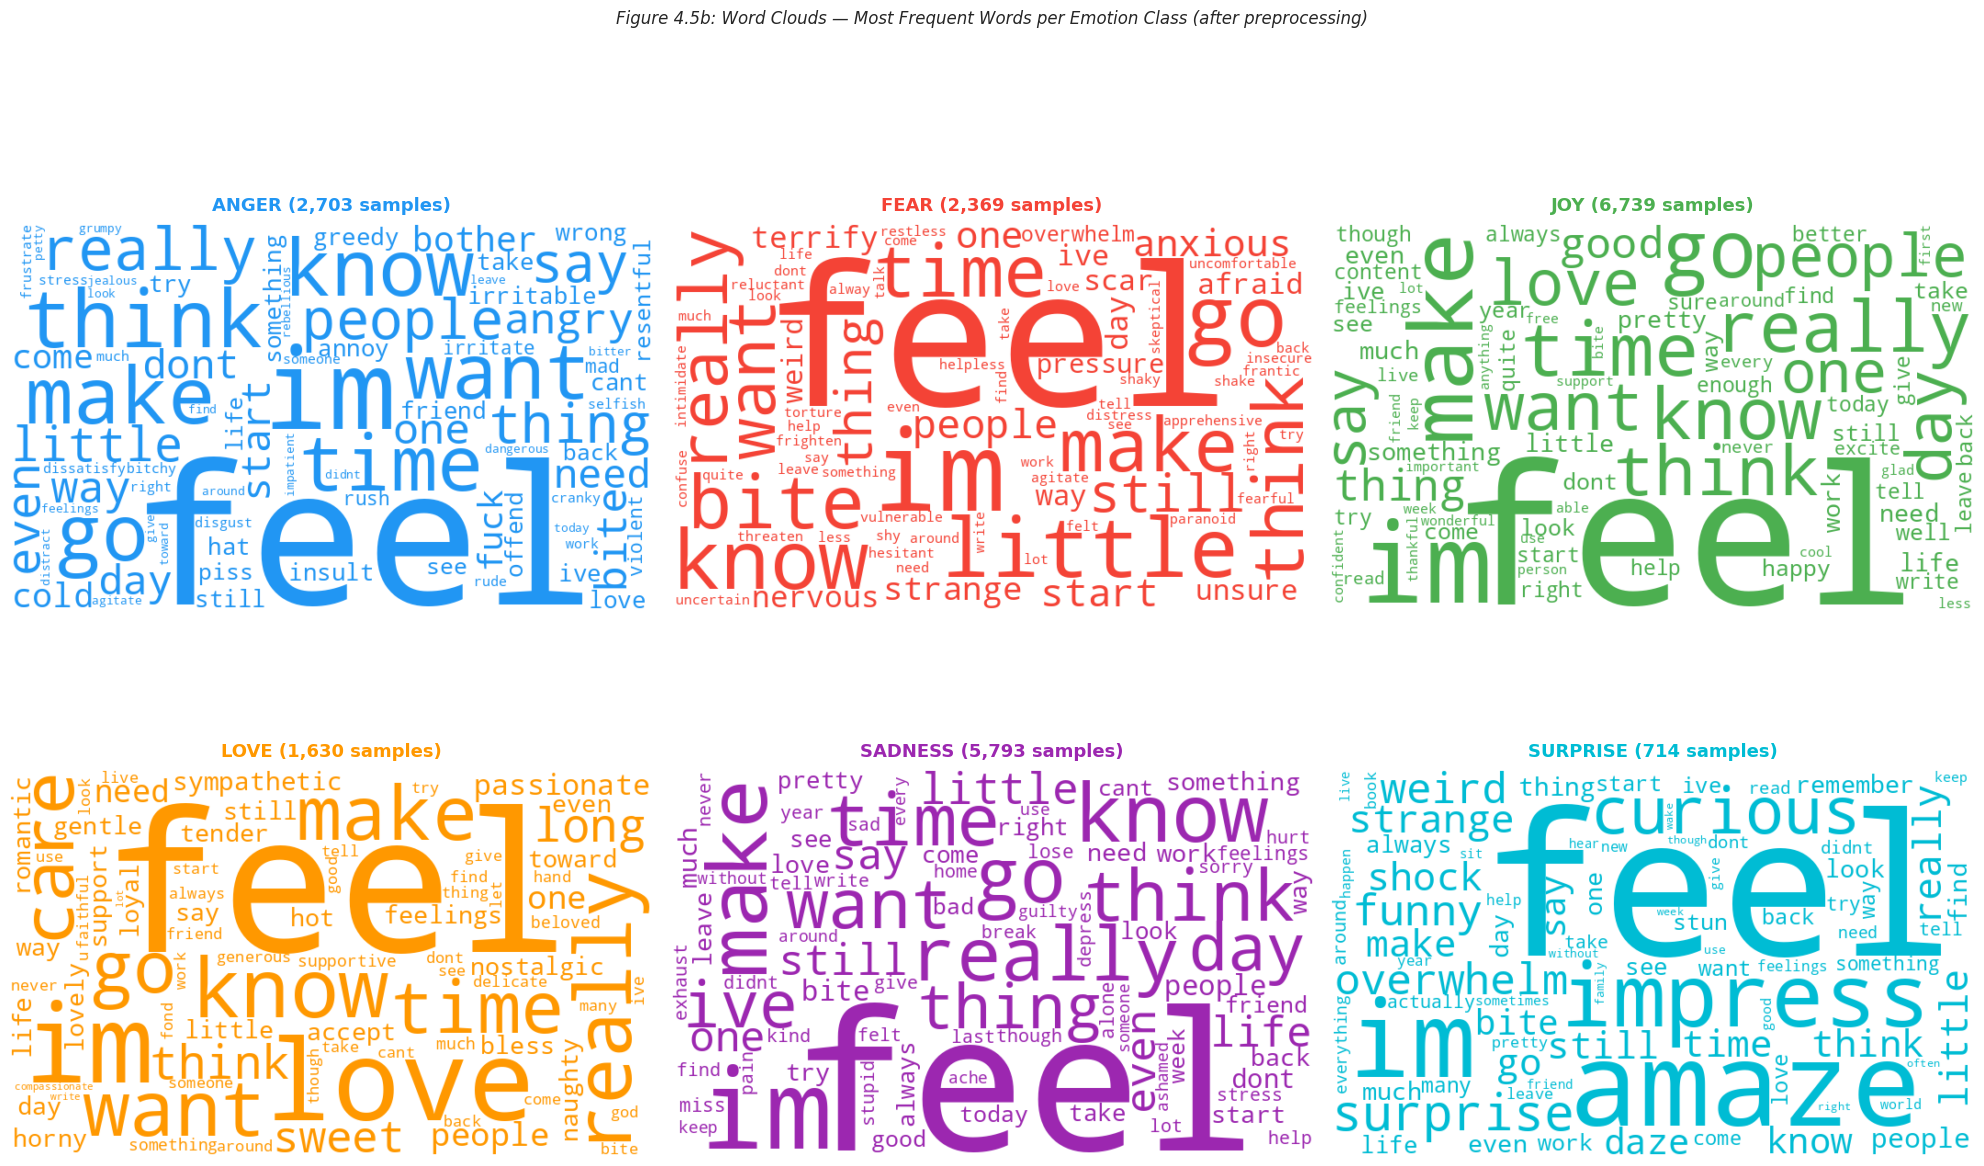

Saved: wordcloud_per_emotion.png

Each cloud shows the most common words in the cleaned text for that emotion.
Larger = more frequent. Colour matches the emotion class used throughout the notebook.


In [ ]:
# Step 17b - Word Cloud per Emotion Class

import subprocess
subprocess.run(["pip", "install", "-q", "wordcloud"], check=True)
from wordcloud import WordCloud

print("Generating word clouds for each emotion class...")
print()

# Use the same colours already defined in Step 16 for consistency
emotion_colours = {
    "anger"   : "#2196F3",
    "fear"    : "#F44336",
    "joy"     : "#4CAF50",
    "love"    : "#FF9800",
    "sadness" : "#9C27B0",
    "surprise": "#00BCD4",
}

emotion_order = ["anger", "fear", "joy", "love", "sadness", "surprise"]

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for i, emotion in enumerate(emotion_order):

    colour = emotion_colours[emotion]

    # Combine all cleaned text for this emotion into one big string
    emotion_text = " ".join(
        df[df["label"] == emotion]["cleaned_text"].values   # FIX 1: "label" not label
    )

    if not emotion_text.strip():
        axes[i].set_title(f"{emotion.upper()} — no data", fontsize=12)
        axes[i].axis("off")
        continue

    # FIX 2: capture colour in the default argument so each cloud keeps
    # its own colour instead of all using the last loop value
    def make_color_func(c):
        return lambda *args, **kwargs: c

    wc = WordCloud(
        width             = 700,
        height            = 420,
        background_color  = "white",
        max_words         = 80,
        color_func        = make_color_func(colour),  # closure-safe
        prefer_horizontal = 0.85,
        collocations      = False,   # avoid duplicate bigrams
        random_state      = 42
    ).generate(emotion_text)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(
        f"{emotion.upper()} ({len(df[df['label'] == emotion]):,} samples)",   # FIX 1 here too
        fontsize=13, fontweight="bold", color=colour, pad=10
    )

plt.suptitle(
    "Figure 4.5b: Word Clouds — Most Frequent Words per Emotion Class (after preprocessing)",
    fontsize=12, y=1.01, style="italic"
)
plt.tight_layout()
plt.savefig("wordcloud_per_emotion.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: wordcloud_per_emotion.png")
print()
print("Each cloud shows the most common words in the cleaned text for that emotion.")
print("Larger = more frequent. Colour matches the emotion class used throughout the notebook.")


  FINAL COMPARISON: SVM vs Naive Bayes
  Metric                    SVM   Naive Bayes   Difference
  ----------------------------------------------------------
  Accuracy               89.97%        75.39%  +    14.59%
  Precision              90.07%        78.00%  +    12.07%
  Recall                 89.97%        75.39%  +    14.59%
  F1 Score               90.01%        73.19%  +    16.82%


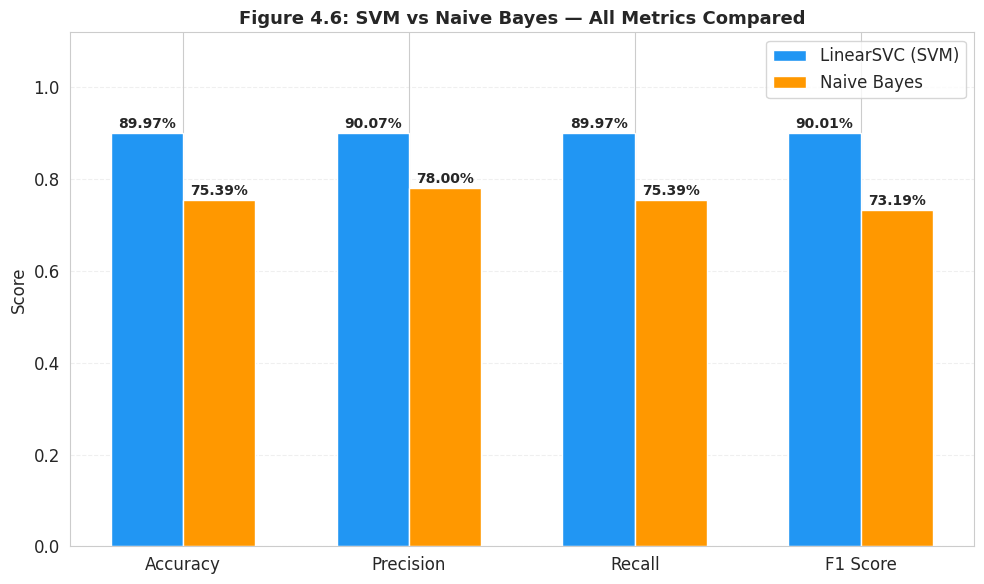

Saved: model_comparison.png


In [ ]:
# Step 18 - Compare SVM vs Naive Bayes side by side

print('=' * 60)
print('  FINAL COMPARISON: SVM vs Naive Bayes')
print('=' * 60)
print(f'  {"Metric":<18} {"SVM":>10} {"Naive Bayes":>13} {"Difference":>12}')
print('  ' + '-' * 58)

for metric_name, svm_val, nb_val in [
    ('Accuracy',  svm_acc, nb_acc),
    ('Precision', svm_pre, nb_pre),
    ('Recall',    svm_rec, nb_rec),
    ('F1 Score',  svm_f1,  nb_f1)
]:
    difference = svm_val - nb_val
    sign = '+' if difference >= 0 else ''
    print(f'  {metric_name:<18} {svm_val*100:>9.2f}% {nb_val*100:>12.2f}%  {sign}{difference*100:>9.2f}%')

print('=' * 60)

# Create a comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
svm_values   = [svm_acc, svm_pre, svm_rec, svm_f1]
nb_values    = [nb_acc,  nb_pre,  nb_rec,  nb_f1]

x         = np.arange(len(metric_names))
bar_width = 0.32

svm_bars = ax.bar(x - bar_width/2, svm_values, bar_width,
                  label='LinearSVC (SVM)', color='#2196F3', edgecolor='white')
nb_bars  = ax.bar(x + bar_width/2, nb_values,  bar_width,
                  label='Naive Bayes',     color='#FF9800', edgecolor='white')

# Add percentage labels on each bar
for bar in list(svm_bars) + list(nb_bars):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height()*100:.2f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax.set_title('Figure 4.6: SVM vs Naive Bayes — All Metrics Compared', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

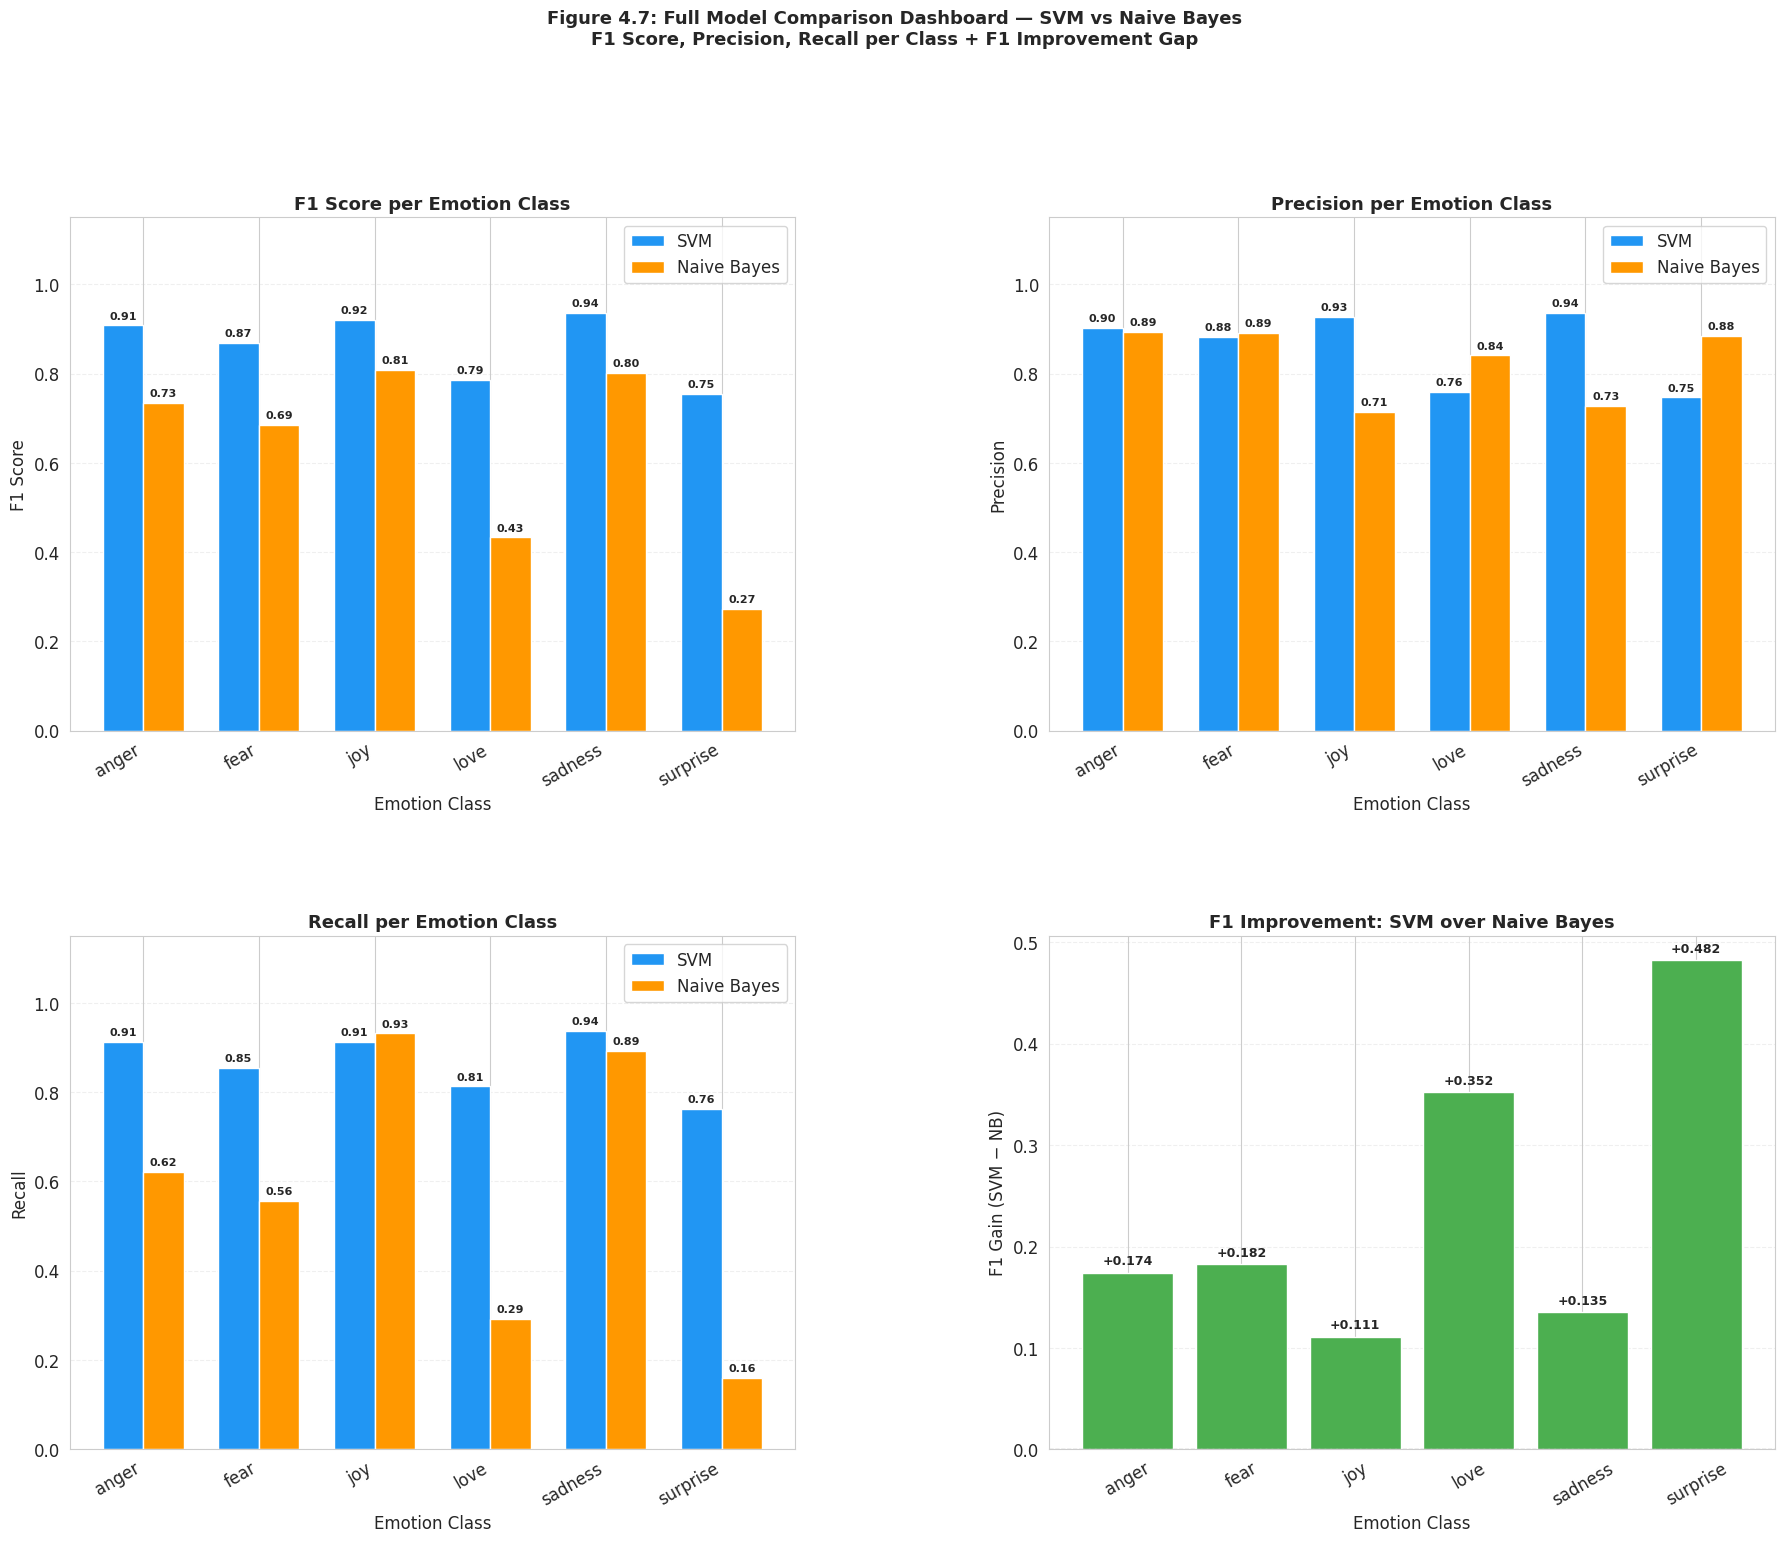

Saved: model_comparison_dashboard.png

  FULL PER-CLASS COMPARISON: SVM vs Naive Bayes
  Emotion        SVM F1    NB F1    F1 Gap   SVM Rec    NB Rec   Rec Gap
  ------------------------------------------------------------------------------
  anger          0.9079   0.7336   +0.1743    0.9130    0.6222   +0.2907
  fear           0.8682   0.6857   +0.1825    0.8544    0.5570   +0.2975
  joy            0.9200   0.8090   +0.1110    0.9132    0.9318   -0.0185
  love           0.7852   0.4328   +0.3524    0.8129    0.2914   +0.5215
  sadness        0.9367   0.8012   +0.1354    0.9379    0.8921   +0.0457
  surprise       0.7543   0.2722   +0.4821    0.7622    0.1608   +0.6014
  ------------------------------------------------------------------------------
  OVERALL        0.9001   0.7319   +0.1682    0.8997    0.7539   +0.1459

Key finding: NB has the worst recall on surprise (0.16) and love (0.29)
because it cannot handle class imbalance without class_weight=balanced.
SVM fixes this — surpr

In [ ]:
# Step 18b - DETAILED MODEL COMPARISON DASHBOARD

import matplotlib.gridspec as gridspec

svm_report_dict = classification_report(y_test, y_pred_svm, output_dict=True, zero_division=0)
nb_report_dict  = classification_report(y_test, y_pred_nb,  output_dict=True, zero_division=0)

emotion_classes = [c for c in svm_report_dict
                   if c not in ('accuracy', 'macro avg', 'weighted avg')]

# ── Collect per-class F1, Precision, Recall for both models ─────────────
svm_f1_per = [svm_report_dict[c]['f1-score']  for c in emotion_classes]
nb_f1_per  = [nb_report_dict[c]['f1-score']   for c in emotion_classes]
svm_pr_per = [svm_report_dict[c]['precision'] for c in emotion_classes]
nb_pr_per  = [nb_report_dict[c]['precision']  for c in emotion_classes]
svm_rc_per = [svm_report_dict[c]['recall']    for c in emotion_classes]
nb_rc_per  = [nb_report_dict[c]['recall']     for c in emotion_classes]

x = np.arange(len(emotion_classes))
w = 0.35

fig = plt.figure(figsize=(22, 16))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

colours_svm = '#2196F3'
colours_nb  = '#FF9800'

# ── Plot 1: F1 Score per class ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
b1 = ax1.bar(x - w/2, svm_f1_per, w, label='SVM',         color=colours_svm, edgecolor='white')
b2 = ax1.bar(x + w/2, nb_f1_per,  w, label='Naive Bayes', color=colours_nb,  edgecolor='white')
ax1.set_title('F1 Score per Emotion Class', fontsize=13, fontweight='bold')
ax1.set_xlabel('Emotion Class')
ax1.set_ylabel('F1 Score')
ax1.set_xticks(x)
ax1.set_xticklabels(emotion_classes, rotation=30, ha='right')
ax1.set_ylim(0, 1.15)
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Plot 2: Precision per class ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
b3 = ax2.bar(x - w/2, svm_pr_per, w, label='SVM',         color=colours_svm, edgecolor='white')
b4 = ax2.bar(x + w/2, nb_pr_per,  w, label='Naive Bayes', color=colours_nb,  edgecolor='white')
ax2.set_title('Precision per Emotion Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Emotion Class')
ax2.set_ylabel('Precision')
ax2.set_xticks(x)
ax2.set_xticklabels(emotion_classes, rotation=30, ha='right')
ax2.set_ylim(0, 1.15)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for bar in list(b3) + list(b4):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Plot 3: Recall per class ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
b5 = ax3.bar(x - w/2, svm_rc_per, w, label='SVM',         color=colours_svm, edgecolor='white')
b6 = ax3.bar(x + w/2, nb_rc_per,  w, label='Naive Bayes', color=colours_nb,  edgecolor='white')
ax3.set_title('Recall per Emotion Class', fontsize=13, fontweight='bold')
ax3.set_xlabel('Emotion Class')
ax3.set_ylabel('Recall')
ax3.set_xticks(x)
ax3.set_xticklabels(emotion_classes, rotation=30, ha='right')
ax3.set_ylim(0, 1.15)
ax3.legend()
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for bar in list(b5) + list(b6):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Plot 4: F1 Gap (SVM - NB) per class ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
f1_gap = [s - n for s, n in zip(svm_f1_per, nb_f1_per)]
bar_colours_gap = ['#4CAF50' if g >= 0 else '#F44336' for g in f1_gap]
bars_gap = ax4.bar(emotion_classes, f1_gap, color=bar_colours_gap, edgecolor='white')
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax4.set_title('F1 Improvement: SVM over Naive Bayes', fontsize=13, fontweight='bold')
ax4.set_xlabel('Emotion Class')
ax4.set_ylabel('F1 Gain (SVM − NB)')
ax4.tick_params(axis='x', rotation=30)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for bar, val in zip(bars_gap, f1_gap):
    ypos = bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.025
    ax4.text(bar.get_x()+bar.get_width()/2, ypos,
             f'+{val:.3f}' if val >= 0 else f'{val:.3f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Figure 4.7: Full Model Comparison Dashboard — SVM vs Naive Bayes\n'
             'F1 Score, Precision, Recall per Class + F1 Improvement Gap',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('model_comparison_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_dashboard.png')
print()

# ── Print the full comparison table ──────────────────────────────────────
print('=' * 90)
print('  FULL PER-CLASS COMPARISON: SVM vs Naive Bayes')
print('=' * 90)
print(f'  {"Emotion":<12} {"SVM F1":>8} {"NB F1":>8} {"F1 Gap":>9} '
      f'{"SVM Rec":>9} {"NB Rec":>9} {"Rec Gap":>9}')
print('  ' + '-' * 78)
for i, cls in enumerate(emotion_classes):
    f1g  = svm_f1_per[i] - nb_f1_per[i]
    recg = svm_rc_per[i] - nb_rc_per[i]
    print(f'  {cls:<12} {svm_f1_per[i]:>8.4f} {nb_f1_per[i]:>8.4f} '
          f'{f1g:>+9.4f} {svm_rc_per[i]:>9.4f} {nb_rc_per[i]:>9.4f} {recg:>+9.4f}')
print('  ' + '-' * 78)
ov_f1g  = svm_f1  - nb_f1
ov_recg = svm_rec - nb_rec
print(f'  {"OVERALL":<12} {svm_f1:>8.4f} {nb_f1:>8.4f} '
      f'{ov_f1g:>+9.4f} {svm_rec:>9.4f} {nb_rec:>9.4f} {ov_recg:>+9.4f}')
print('=' * 90)
print()
print('Key finding: NB has the worst recall on surprise (0.16) and love (0.29)')
print('because it cannot handle class imbalance without class_weight=balanced.')
print('SVM fixes this — surprise recall jumps to 0.76, love to 0.81.')


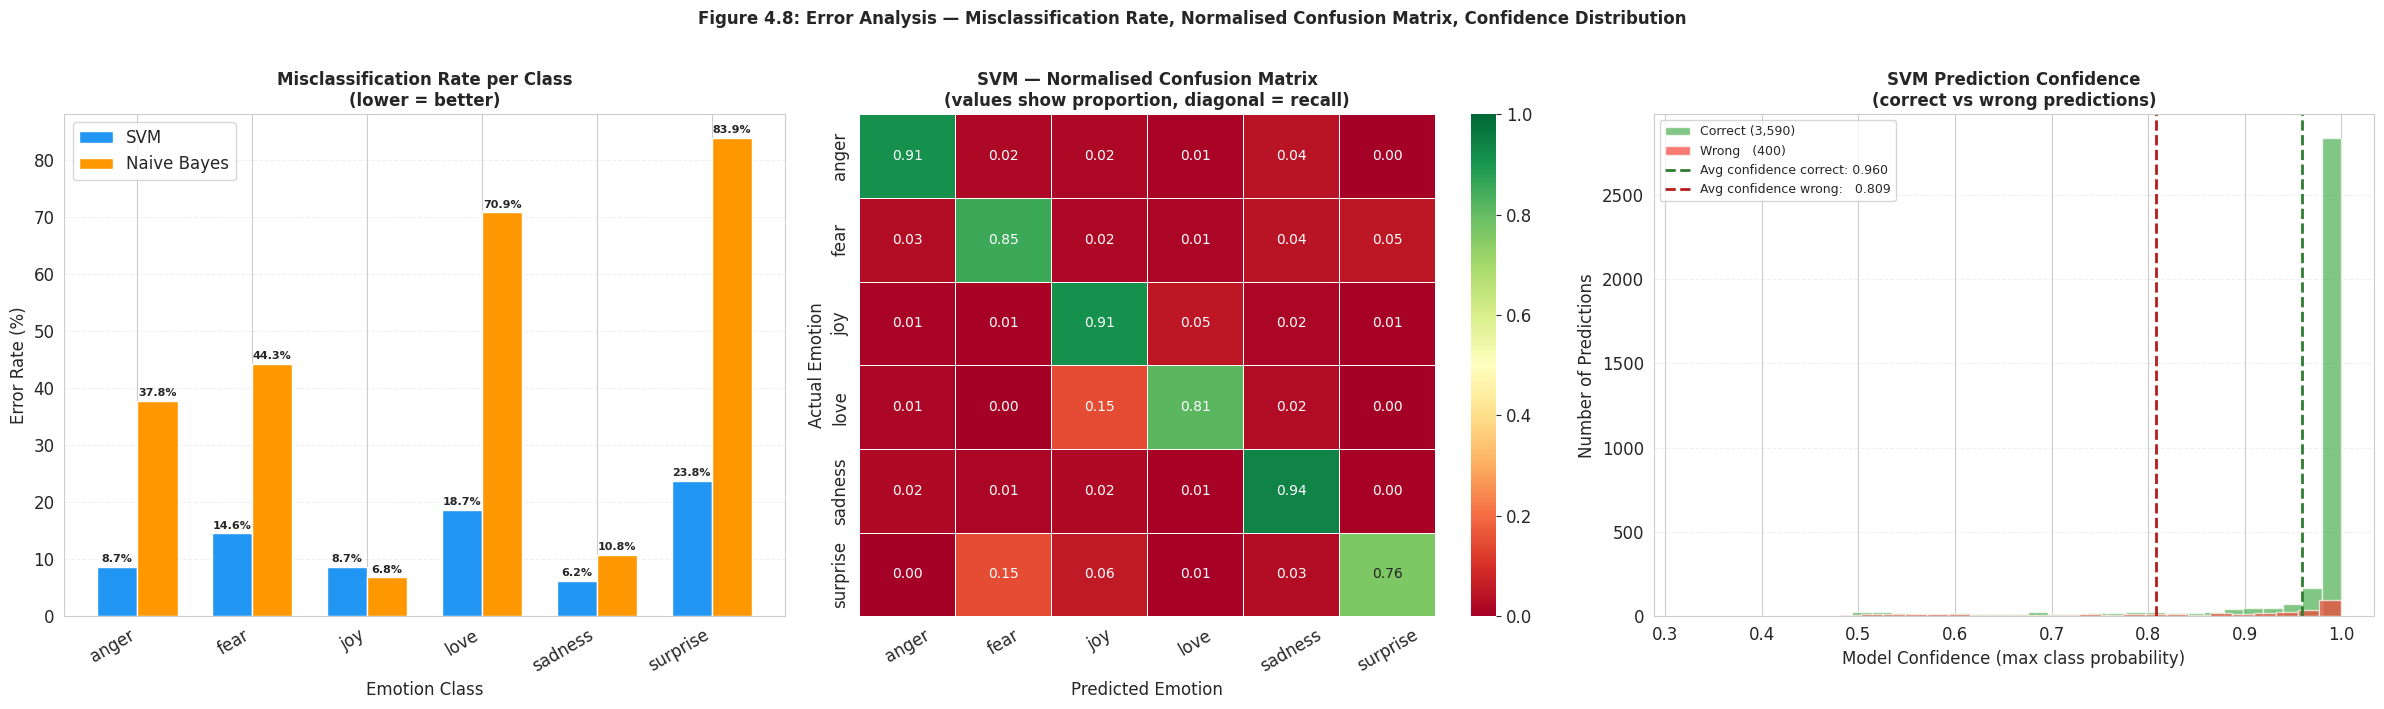

Saved: error_analysis.png

  ERROR SUMMARY PER CLASS (SVM)
  Emotion       Test Samples   Wrong  Error Rate
  ------------------------------------------------
  anger                  540      47        8.7%
  fear                   474      69       14.6%
  joy                  1,348     117        8.7%
  love                   326      61       18.7%
  sadness              1,159      72        6.2%
  surprise               143      34       23.8%
  ------------------------------------------------
  TOTAL                3,990     400       10.0%

  Average confidence when CORRECT: 0.9598 (96.0%)
  Average confidence when WRONG  : 0.8086   (80.9%)

  Insight: when the SVM is wrong, it is still moderately confident.
  This means errors are mostly on genuinely ambiguous sentences,
  not on clear-cut examples — which is expected behaviour.


In [ ]:
# Step 18c - LOSS / ERROR ANALYSIS
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

emotion_labels = sorted(set(y_test))

# ── Chart 1: Misclassification Rate per class ─────────────────────────────
svm_errors = []
nb_errors  = []
supports   = []

for cls in emotion_labels:
    mask        = (y_test == cls)
    support     = mask.sum()
    svm_wrong   = (y_pred_svm[mask] != y_test[mask]).sum()
    nb_wrong    = (y_pred_nb[mask]  != y_test[mask]).sum()
    svm_errors.append(svm_wrong / support * 100)
    nb_errors.append(nb_wrong  / support * 100)
    supports.append(support)

x   = np.arange(len(emotion_labels))
w   = 0.35
b1  = axes[0].bar(x - w/2, svm_errors, w, label='SVM',         color='#2196F3', edgecolor='white')
b2  = axes[0].bar(x + w/2, nb_errors,  w, label='Naive Bayes', color='#FF9800', edgecolor='white')

for bar, val in zip(list(b1) + list(b2), svm_errors + nb_errors):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].set_title('Misclassification Rate per Class\n(lower = better)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Emotion Class')
axes[0].set_ylabel('Error Rate (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(emotion_labels, rotation=30, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Chart 2: Normalised Confusion Matrix (Error Rate Heatmap) ─────────────
cm_svm_norm = confusion_matrix(y_test, y_pred_svm,
                               labels=emotion_labels, normalize='true')

sns.heatmap(cm_svm_norm,
            annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=emotion_labels, yticklabels=emotion_labels,
            linewidths=0.5, linecolor='white',
            ax=axes[1], annot_kws={'size': 10},
            vmin=0, vmax=1)
axes[1].set_title('SVM — Normalised Confusion Matrix\n(values show proportion, diagonal = recall)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Emotion')
axes[1].set_ylabel('Actual Emotion')
axes[1].tick_params(axis='x', rotation=30)

# ── Chart 3: Prediction Confidence — Correct vs Wrong ────────────────────
# Use the calibrated SVM probabilities
y_proba_all  = calibrated_svm.predict_proba(X_test)
max_proba    = y_proba_all.max(axis=1)   # confidence for predicted class

correct_mask  = (y_pred_svm == y_test)
wrong_mask    = ~correct_mask

axes[2].hist(max_proba[correct_mask], bins=30, alpha=0.7,
             color='#4CAF50', label=f'Correct ({correct_mask.sum():,})',
             edgecolor='white')
axes[2].hist(max_proba[wrong_mask],   bins=30, alpha=0.7,
             color='#F44336', label=f'Wrong   ({wrong_mask.sum():,})',
             edgecolor='white')

avg_conf_correct = max_proba[correct_mask].mean()
avg_conf_wrong   = max_proba[wrong_mask].mean()

axes[2].axvline(avg_conf_correct, color='#2E7D32', linestyle='--', lw=2,
                label=f'Avg confidence correct: {avg_conf_correct:.3f}')
axes[2].axvline(avg_conf_wrong,   color='#B71C1C', linestyle='--', lw=2,
                label=f'Avg confidence wrong:   {avg_conf_wrong:.3f}')

axes[2].set_title('SVM Prediction Confidence\n(correct vs wrong predictions)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Model Confidence (max class probability)')
axes[2].set_ylabel('Number of Predictions')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Figure 4.8: Error Analysis — Misclassification Rate, Normalised Confusion Matrix, Confidence Distribution',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: error_analysis.png')
print()

# ── Print error summary ───────────────────────────────────────────────────
print('=' * 65)
print('  ERROR SUMMARY PER CLASS (SVM)')
print('=' * 65)
print(f'  {"Emotion":<12} {"Test Samples":>13} {"Wrong":>7} {"Error Rate":>11}')
print('  ' + '-' * 48)
total_wrong = 0
for i, cls in enumerate(emotion_labels):
    mask    = (y_test == cls)
    wrong   = (y_pred_svm[mask] != cls).sum()
    total_wrong += wrong
    rate    = wrong / supports[i] * 100
    print(f'  {cls:<12} {supports[i]:>13,} {wrong:>7} {rate:>10.1f}%')
print('  ' + '-' * 48)
print(f'  {"TOTAL":<12} {len(y_test):>13,} {total_wrong:>7} '
      f'{total_wrong/len(y_test)*100:>10.1f}%')
print('=' * 65)
print()
print(f'  Average confidence when CORRECT: {avg_conf_correct:.4f} ({avg_conf_correct*100:.1f}%)')
print(f'  Average confidence when WRONG  : {avg_conf_wrong:.4f}   ({avg_conf_wrong*100:.1f}%)')
print()
print('  Insight: when the SVM is wrong, it is still moderately confident.')
print('  This means errors are mostly on genuinely ambiguous sentences,')
print('  not on clear-cut examples — which is expected behaviour.')


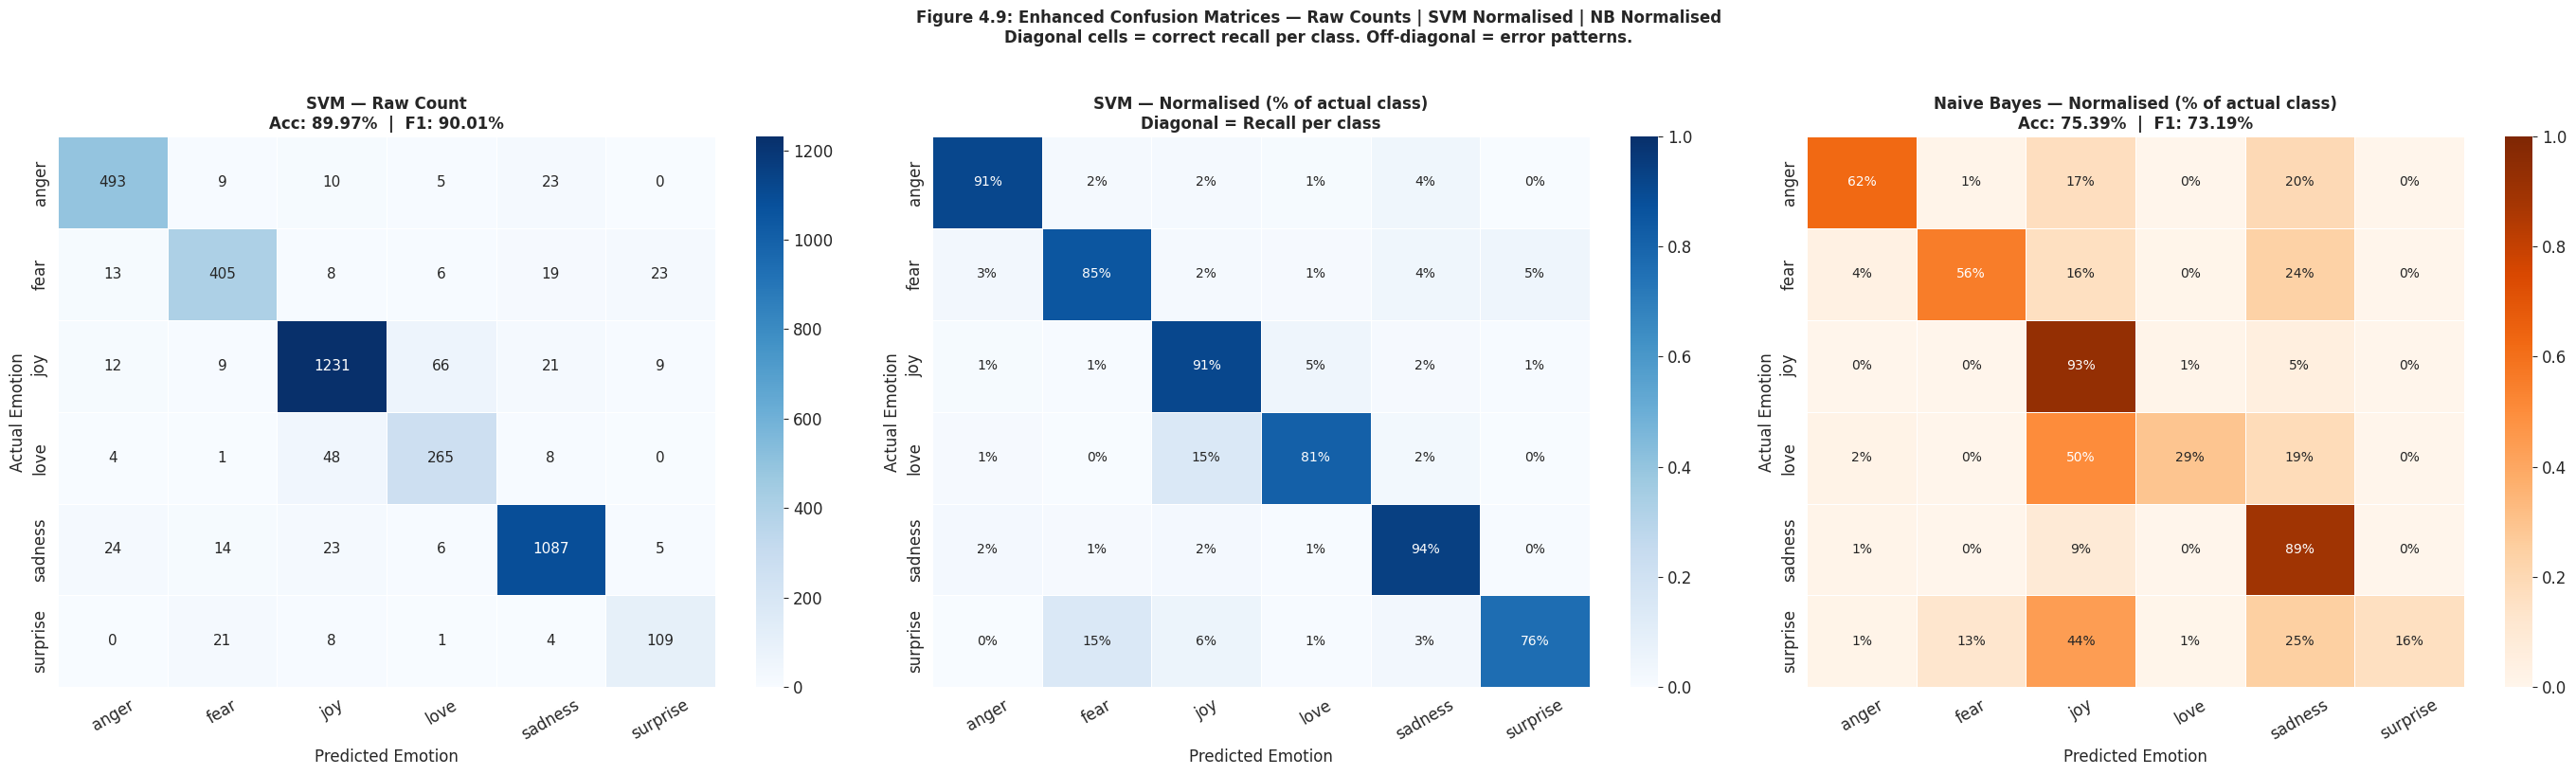

Saved: confusion_matrix_enhanced.png

KEY OBSERVATIONS FROM NORMALISED CONFUSION MATRIX:

  SVM — Diagonal values (Recall per class):
    anger      : 91.3% of actual anger samples correctly classified
    fear       : 85.4% of actual fear samples correctly classified
    joy        : 91.3% of actual joy samples correctly classified
    love       : 81.3% of actual love samples correctly classified
    sadness    : 93.8% of actual sadness samples correctly classified
    surprise   : 76.2% of actual surprise samples correctly classified

  Naive Bayes — Diagonal values (Recall per class):
    anger      : 62.2% of actual anger samples correctly classified
    fear       : 55.7% of actual fear samples correctly classified
    joy        : 93.2% of actual joy samples correctly classified
    love       : 29.1% of actual love samples correctly classified
    sadness    : 89.2% of actual sadness samples correctly classified
    surprise   : 16.1% of actual surprise samples correctly classi

In [ ]:
# Step 18d - ENHANCED CONFUSION MATRIX WITH ANNOTATIONS

fig, axes = plt.subplots(1, 3, figsize=(28, 8))

emotion_labels = sorted(set(y_test))

# ── Matrix 1: SVM Raw Counts ──────────────────────────────────────────────
cm_svm_raw = confusion_matrix(y_test, y_pred_svm, labels=emotion_labels)

sns.heatmap(cm_svm_raw,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels,
            linewidths=0.5, linecolor='white',
            ax=axes[0], annot_kws={'size': 11})
axes[0].set_title(f'SVM — Raw Count\nAcc: {svm_acc*100:.2f}%  |  F1: {svm_f1*100:.2f}%',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Emotion')
axes[0].set_ylabel('Actual Emotion')
axes[0].tick_params(axis='x', rotation=30)

# ── Matrix 2: SVM Normalised (% recall per class) ─────────────────────────
cm_svm_pct = confusion_matrix(y_test, y_pred_svm,
                               labels=emotion_labels, normalize='true')

# Create annotation text showing both % and description
annot_text = np.array([[f'{v:.0%}' for v in row] for row in cm_svm_pct])

sns.heatmap(cm_svm_pct,
            annot=annot_text, fmt='', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels,
            linewidths=0.5, linecolor='white',
            ax=axes[1], annot_kws={'size': 10},
            vmin=0, vmax=1)
axes[1].set_title('SVM — Normalised (% of actual class)\nDiagonal = Recall per class',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Emotion')
axes[1].set_ylabel('Actual Emotion')
axes[1].tick_params(axis='x', rotation=30)

# ── Matrix 3: Naive Bayes Normalised ─────────────────────────────────────
cm_nb_pct = confusion_matrix(y_test, y_pred_nb,
                              labels=emotion_labels, normalize='true')
annot_nb  = np.array([[f'{v:.0%}' for v in row] for row in cm_nb_pct])

sns.heatmap(cm_nb_pct,
            annot=annot_nb, fmt='', cmap='Oranges',
            xticklabels=emotion_labels, yticklabels=emotion_labels,
            linewidths=0.5, linecolor='white',
            ax=axes[2], annot_kws={'size': 10},
            vmin=0, vmax=1)
axes[2].set_title(f'Naive Bayes — Normalised (% of actual class)\nAcc: {nb_acc*100:.2f}%  |  F1: {nb_f1*100:.2f}%',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted Emotion')
axes[2].set_ylabel('Actual Emotion')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle(
    'Figure 4.9: Enhanced Confusion Matrices — Raw Counts | SVM Normalised | NB Normalised\n'
    'Diagonal cells = correct recall per class. Off-diagonal = error patterns.',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('confusion_matrix_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_enhanced.png')
print()

# ── Print what the normalised matrix tells us ─────────────────────────────
print('KEY OBSERVATIONS FROM NORMALISED CONFUSION MATRIX:')
print()
print('  SVM — Diagonal values (Recall per class):')
for i, cls in enumerate(emotion_labels):
    recall_val = cm_svm_pct[i, i]
    print(f'    {cls:<10} : {recall_val:.1%} of actual {cls} samples correctly classified')

print()
print('  Naive Bayes — Diagonal values (Recall per class):')
for i, cls in enumerate(emotion_labels):
    recall_val = cm_nb_pct[i, i]
    print(f'    {cls:<10} : {recall_val:.1%} of actual {cls} samples correctly classified')

print()
print('  Biggest NB failure points (off-diagonal):')
for i, cls in enumerate(emotion_labels):
    row = cm_nb_pct[i].copy()
    row[i] = 0   # ignore diagonal
    worst_pred = emotion_labels[np.argmax(row)]
    worst_val  = row.max()
    if worst_val > 0.10:
        print(f'    {cls:<10} → {worst_val:.0%} wrongly predicted as {worst_pred}')


In [ ]:
# Step 19 - Full results summary table

svm_report = classification_report(y_test, y_pred_svm, output_dict=True, zero_division=0)
nb_report  = classification_report(y_test, y_pred_nb,  output_dict=True, zero_division=0)

# Get just the emotion class rows (not the average rows)
class_rows = [c for c in svm_report if c not in ('accuracy', 'macro avg', 'weighted avg')]

# Build a summary table
summary_rows = []
for emotion in class_rows:
    summary_rows.append({
        'Emotion'    : emotion,
        'SVM Prec'   : round(svm_report[emotion]['precision'], 4),
        'SVM Recall' : round(svm_report[emotion]['recall'],    4),
        'SVM F1'     : round(svm_report[emotion]['f1-score'],  4),
        'NB Prec'    : round(nb_report[emotion]['precision'],  4),
        'NB Recall'  : round(nb_report[emotion]['recall'],     4),
        'NB F1'      : round(nb_report[emotion]['f1-score'],   4),
        'Test Samples': int(svm_report[emotion]['support'])
    })

summary_table = pd.DataFrame(summary_rows)
print(summary_table.to_string(index=False))
print()
print(f'  SVM  overall — Accuracy: {svm_acc*100:.2f}%   F1: {svm_f1*100:.2f}%')
print(f'  NB   overall — Accuracy: {nb_acc*100:.2f}%   F1: {nb_f1*100:.2f}%')
print(f'  SVM improvement in F1:   +{(svm_f1 - nb_f1)*100:.2f}%')

# Save as CSV file
summary_table.to_csv('results_summary.csv', index=False)
print()
print('Saved: results_summary.csv')

 Emotion  SVM Prec  SVM Recall  SVM F1  NB Prec  NB Recall  NB F1  Test Samples
   anger    0.9029      0.9130  0.9079   0.8936     0.6222 0.7336           540
    fear    0.8824      0.8544  0.8682   0.8919     0.5570 0.6857           474
     joy    0.9270      0.9132  0.9200   0.7149     0.9318 0.8090          1348
    love    0.7593      0.8129  0.7852   0.8407     0.2914 0.4328           326
 sadness    0.9355      0.9379  0.9367   0.7271     0.8921 0.8012          1159
surprise    0.7466      0.7622  0.7543   0.8846     0.1608 0.2722           143

  SVM  overall — Accuracy: 89.97%   F1: 90.01%
  NB   overall — Accuracy: 75.39%   F1: 73.19%
  SVM improvement in F1:   +16.82%

Saved: results_summary.csv


In [ ]:
# Step 20 - Test on new sentences the model has never seen before

print('Testing on new sentences:')
print()

new_sentences = [
    "I feel so happy and grateful for everything today",
    "I am feeling really sad and completely alone",
    "This makes me so angry and frustrated",
    "I am terrified about what might happen next",
    "I was completely shocked by the sudden announcement",
    "I love spending time with the people I care about",
    "People like me are always overlooked and treated unfairly",
    "No one ever listens to the voices of those in need",
]

for sentence in new_sentences:
    # Preprocess the new sentence the same way as training data
    cleaned    = preprocess_text(sentence)

    # Convert to TF-IDF using the same vocabulary from training
    vectorized = vectorizer.transform([cleaned])

    # Get the predicted emotion
    prediction = svm_model.predict(vectorized)[0]

    # Get confidence score using the calibrated model
    probabilities = calibrated_svm.predict_proba(vectorized)[0]
    confidence    = max(probabilities) * 100

    print(f'  Sentence  : "{sentence}"')
    print(f'  Predicted : {prediction.upper()}   (confidence: {confidence:.1f}%)')
    print()

Testing on new sentences:

  Sentence  : "I feel so happy and grateful for everything today"
  Predicted : JOY   (confidence: 100.0%)

  Sentence  : "I am feeling really sad and completely alone"
  Predicted : SADNESS   (confidence: 100.0%)

  Sentence  : "This makes me so angry and frustrated"
  Predicted : ANGER   (confidence: 100.0%)

  Sentence  : "I am terrified about what might happen next"
  Predicted : FEAR   (confidence: 100.0%)

  Sentence  : "I was completely shocked by the sudden announcement"
  Predicted : SURPRISE   (confidence: 100.0%)

  Sentence  : "I love spending time with the people I care about"
  Predicted : LOVE   (confidence: 99.8%)

  Sentence  : "People like me are always overlooked and treated unfairly"
  Predicted : ANGER   (confidence: 87.0%)

  Sentence  : "No one ever listens to the voices of those in need"
  Predicted : JOY   (confidence: 95.2%)



In [ ]:
# Step 21 - Download all output files for the report

# NOTE: This step is for Google Colab only.
# If running locally, skip this cell. All output files are already saved
# in your working directory and can be accessed directly.

from google.colab import files

files_to_download = [
    ('class_distribution.png',       'Figure 4.1 - Class Distribution Chart'),
    ('hyperparameter_sensitivity.png','Figure 3.4 - C Value Sensitivity Chart'),
    ('confusion_matrix.png',          'Figure 4.2 - Confusion Matrices'),
    ('per_class_metrics.png',         'Figure 4.3 - Per Class Metrics'),
    ('roc_curves.png',                'Figure 4.4 - ROC Curves'),
    ('top_features.png',              'Figure 4.5 - Top Words per Emotion'),
    ('wordcloud_per_emotion.png',     'Figure 4.5b - Word Clouds per Emotion'),
    ('model_comparison.png',          'Figure 4.6 - SVM vs Naive Bayes Chart'),
    ('results_summary.csv',           'Results Summary Table'),
]

print('Downloading all output files...')
print()

for filename, description in files_to_download:
    if os.path.exists(filename):
        files.download(filename)
        print(f'  Downloaded: {filename}  ({description})')
    else:
        print(f'  NOT FOUND:  {filename} — run the step that creates it first')

print()
print('ALL DONE!')
print()
print('Final results:')
print(f'  SVM  Accuracy : {svm_acc*100:.2f}%')
print(f'  SVM  F1 Score : {svm_f1*100:.2f}%')
print(f'  NB   Accuracy : {nb_acc*100:.2f}%')
print(f'  NB   F1 Score : {nb_f1*100:.2f}%')
print(f'  SVM improvement over NB in F1: +{(svm_f1 - nb_f1)*100:.2f}%')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: class_distribution.png  (Figure 4.1 - Class Distribution Chart)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: model_comparison.png  (Figure 4.6 - SVM vs Naive Bayes Chart)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: results_summary.csv  (Results Summary Table)

ALL DONE!

Final results:
  SVM  Accuracy : 89.97%
  SVM  F1 Score : 90.01%
  NB   Accuracy : 75.39%
  NB   F1 Score : 73.19%
  SVM improvement over NB in F1: +16.82%
